# Task 5 — Walk-Forward Optimization and Out-of-Sample Evaluation

This notebook performs rolling walk-forward optimization of the validated
**Channel WithDDControl** strategy on CBOT Soybeans (SY).

For each walk-forward window:

- the preceding **4 years** form the in-sample optimization period;
- the immediately following **3 months** form the out-of-sample evaluation period;
- `ChnLen` is searched from **500 to 10,000 in steps of 10**;
- `StpPct` is searched from **0.005 to 0.100 in steps of 0.001**;
- the optimization objective is **Net Profit / |Maximum Drawdown|**.

The full parameter grid contains **951 × 96 = 91,296 combinations per in-sample window**.

The cleaned SY dataset from Task 2 and the contract economics validated in Tasks 1
and 4 are used consistently throughout the analysis.

Parameters are selected using in-sample data only and are then frozen during the
subsequent out-of-sample quarter. The purpose of the walk-forward framework is to
evaluate whether the strategy generalizes beyond the historical data used for
parameter selection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:,.4f}'.format)


# 0. Configuration

# Validated cleaned dataset from Task 2
CLEAN = Path('data') / 'clean'
SY_PATH = CLEAN / 'SY.parquet'

# SY contract economics
PV = 50.0
SLPG = 35.5
INITIAL_EQUITY = 100_000.0

# Full professor-required parameter grid
CHNLEN_RANGE = np.arange(
    500,
    10_001,
    10
)

STPPCT_RANGE = np.round(
    np.arange(
        0.005,
        0.101,
        0.001
    ),
    3
)

# Walk-forward design
IS_YEARS = 4
OOS_MONTHS = 3


print('=' * 60)
print('TASK 5 CONFIGURATION')
print('=' * 60)

print(f'Point value          : ${PV:g}')
print(f'Round-turn slippage  : ${SLPG:.2f}')
print(f'Initial equity       : ${INITIAL_EQUITY:,.2f}')

print()

print(f'ChnLen grid size     : {len(CHNLEN_RANGE)}')
print(f'StpPct grid size     : {len(STPPCT_RANGE)}')
print(
    f'Total combinations   : '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print()

print(f'In-sample window     : {IS_YEARS} years')
print(f'OOS window           : {OOS_MONTHS} months')


TASK 5 CONFIGURATION
Point value          : $50
Round-turn slippage  : $35.50
Initial equity       : $100,000.00

ChnLen grid size     : 951
StpPct grid size     : 96
Total combinations   : 91,296

In-sample window     : 4 years
OOS window           : 3 months


## 1. Load Validated SY Data

In [2]:
if not SY_PATH.exists():
    raise FileNotFoundError(
        f'{SY_PATH} not found. Please run Task 2 first.'
    )

sy = pd.read_parquet(
    SY_PATH
).copy()

sy['ts'] = pd.to_datetime(
    sy['ts']
)

required_cols = [
    'ts',
    'Open',
    'High',
    'Low',
    'Close'
]

missing_cols = [
    col
    for col in required_cols
    if col not in sy.columns
]

if missing_cols:
    raise ValueError(
        f'SY cleaned dataset is missing required columns: '
        f'{missing_cols}'
    )

sy = (
    sy
    .sort_values('ts')
    .drop_duplicates(
        subset='ts',
        keep='last'
    )
    .reset_index(drop=True)
)

# Numpy arrays used by the optimization engine
ts = sy['ts'].to_numpy()

Open = sy['Open'].to_numpy(
    dtype=float
)

High = sy['High'].to_numpy(
    dtype=float
)

Low = sy['Low'].to_numpy(
    dtype=float
)

Close = sy['Close'].to_numpy(
    dtype=float
)

N = len(sy)

print()
print('=' * 60)
print('VALIDATED SY DATA')
print('=' * 60)

print(
    f'Rows                 : {N:,}'
)

print(
    f'Date range           : '
    f'{sy["ts"].min()} → {sy["ts"].max()}'
)

print(
    f'First close          : {Close[0]:,.2f}'
)

print(
    f'Last close           : {Close[-1]:,.2f}'
)


VALIDATED SY DATA
Rows                 : 495,740
Date range           : 1982-07-01 09:35:00 → 2026-04-10 13:15:00
First close          : 617.50
Last close           : 1,175.25


## 2. Walk-Forward Window Construction

Each walk-forward iteration uses a strictly chronological design:

- **In-sample (IS):** the preceding 4 years;
- **Out-of-sample (OOS):** the immediately following 3 months;
- the window then advances by 3 months.

The OOS period is never used during parameter selection. This preserves the
temporal ordering required for genuine out-of-sample evaluation.

Each window stores both timestamp boundaries and corresponding bar indices so that
subsequent optimization and OOS backtesting operate on exactly defined samples.

In [3]:
# 2. Build Walk-Forward Calendar

ts_pd = pd.DatetimeIndex(sy['ts'])

first_date = ts_pd[0]
last_date = ts_pd[-1]

windows = []

# First OOS period begins after four complete years of history
oos_start = first_date + pd.DateOffset(years=IS_YEARS)

while True:

    oos_end = (
        oos_start
        + pd.DateOffset(months=OOS_MONTHS)
    )

    # Stop when a complete OOS quarter is no longer available
    if oos_end > last_date:
        break

    is_start = (
        oos_start
        - pd.DateOffset(years=IS_YEARS)
    )

    is_end = oos_start

    # --------------------------------------------------------
    # Locate IS and OOS bars
    # --------------------------------------------------------

    is_mask = (
        (ts_pd >= is_start)
        & (ts_pd < is_end)
    )

    oos_mask = (
        (ts_pd >= oos_start)
        & (ts_pd < oos_end)
    )

    is_idx = np.flatnonzero(is_mask)
    oos_idx = np.flatnonzero(oos_mask)

    # Skip incomplete / invalid windows
    if (
        len(is_idx) == 0
        or len(oos_idx) == 0
    ):
        oos_start = oos_end
        continue

    windows.append({
        'Quarter': (
            f'{oos_start.year}Q'
            f'{oos_start.quarter}'
        ),

        'IS_Start': is_start,
        'IS_End': is_end,

        'OOS_Start': oos_start,
        'OOS_End': oos_end,

        'IS_i0': int(is_idx[0]),
        'IS_i1': int(is_idx[-1]),

        'OOS_i0': int(oos_idx[0]),
        'OOS_i1': int(oos_idx[-1]),

        'IS_Bars': int(len(is_idx)),
        'OOS_Bars': int(len(oos_idx))
    })

    # Roll forward one quarter
    oos_start = oos_end


windows_df = pd.DataFrame(windows)

print('=' * 60)
print('WALK-FORWARD CALENDAR')
print('=' * 60)

print(
    f'Total OOS quarters   : {len(windows_df)}'
)

print(
    f'First OOS quarter    : '
    f'{windows_df.iloc[0]["Quarter"]}'
)

print(
    f'First OOS period     : '
    f'{windows_df.iloc[0]["OOS_Start"]} → '
    f'{windows_df.iloc[0]["OOS_End"]}'
)

print(
    f'Last OOS quarter     : '
    f'{windows_df.iloc[-1]["Quarter"]}'
)

print(
    f'Last OOS period      : '
    f'{windows_df.iloc[-1]["OOS_Start"]} → '
    f'{windows_df.iloc[-1]["OOS_End"]}'
)

print(
    f'Typical IS bars      : '
    f'{int(windows_df["IS_Bars"].median()):,}'
)

print(
    f'Typical OOS bars     : '
    f'{int(windows_df["OOS_Bars"].median()):,}'
)

windows_df.head()

WALK-FORWARD CALENDAR
Total OOS quarters   : 159
First OOS quarter    : 1986Q3
First OOS period     : 1986-07-01 09:35:00 → 1986-10-01 09:35:00
Last OOS quarter     : 2026Q1
Last OOS period      : 2026-01-01 09:35:00 → 2026-04-01 09:35:00
Typical IS bars      : 45,254
Typical OOS bars     : 2,835


,Quarter,IS_Start,IS_End,OOS_Start,OOS_End,IS_i0,IS_i1,OOS_i0,OOS_i1,IS_Bars,OOS_Bars
0,1986Q3,1982-07-01 09:35:00,1986-07-01 09:35:00,1986-07-01 09:35:00,1986-10-01 09:35:00,0,45539,45540,48419,45540,2880
1,1986Q4,1982-10-01 09:35:00,1986-10-01 09:35:00,1986-10-01 09:35:00,1987-01-01 09:35:00,2880,48419,48420,51299,45540,2880
2,1987Q1,1983-01-01 09:35:00,1987-01-01 09:35:00,1987-01-01 09:35:00,1987-04-01 09:35:00,5760,51299,51300,54089,45540,2790
3,1987Q2,1983-04-01 09:35:00,1987-04-01 09:35:00,1987-04-01 09:35:00,1987-07-01 09:35:00,8595,54089,54090,56924,45495,2835
4,1987Q3,1983-07-01 09:35:00,1987-07-01 09:35:00,1987-07-01 09:35:00,1987-10-01 09:35:00,11430,56924,56925,59804,45495,2880


### 2.1 Walk-Forward Boundary Validation

Before optimization, the walk-forward calendar is checked programmatically to
verify that every OOS period begins strictly after its corresponding IS sample
and that consecutive OOS quarters do not overlap.

These checks ensure that future observations cannot enter the parameter-selection
stage.

In [4]:
# Walk-forward boundary validation

validation = pd.DataFrame({
    'Check': [
        'IS ends immediately before OOS begins',
        'IS and OOS indices do not overlap',
        'OOS quarters do not overlap',
        'All IS windows contain observations',
        'All OOS windows contain observations'
    ],

    'Passed': [
        bool(
            (
                windows_df['OOS_i0']
                == windows_df['IS_i1'] + 1
            ).all()
        ),

        bool(
            (
                windows_df['IS_i1']
                < windows_df['OOS_i0']
            ).all()
        ),

        bool(
            (
                windows_df['OOS_i0'].iloc[1:].to_numpy()
                > windows_df['OOS_i1'].iloc[:-1].to_numpy()
            ).all()
        ),

        bool(
            (windows_df['IS_Bars'] > 0).all()
        ),

        bool(
            (windows_df['OOS_Bars'] > 0).all()
        )
    ]
})

validation

,Check,Passed
0,IS ends immediately before OOS begins,True
1,IS and OOS indices do not overlap,True
2,OOS quarters do not overlap,True
3,All IS windows contain observations,True
4,All OOS windows contain observations,True


## 3. Fast In-Sample Optimization Engine

The full in-sample parameter grid contains **91,296 combinations per walk-forward
window**. Re-running the full diagnostic backtest from Task 4 for every parameter
pair would be computationally inefficient because trade ledgers, event logs, and
plots are unnecessary during parameter search.

This section therefore implements a lightweight scoring engine that preserves the
same Channel WithDDControl trading rules while returning only the quantities needed
for optimization:

- net profit;
- maximum drawdown;
- the optimization objective, `Net Profit / |Maximum Drawdown|`.

The full diagnostic engine is used only after the optimal parameter pair has been
selected.

Before launching the complete walk-forward experiment, the fast engine is checked
against the validated Task 4 logic on a single parameter pair.

In [5]:
# 3. Fast In-Sample Scoring Engine

try:
    from numba import njit
    NUMBA_AVAILABLE = True
    print('Numba available: using compiled optimization engine.')
except ImportError:
    NUMBA_AVAILABLE = False
    print(
        'Numba is not installed. '
        'The exhaustive optimizer will be too slow without compilation.'
    )


if NUMBA_AVAILABLE:

    @njit(cache=True)
    def score_strategy_fast(
        high,
        low,
        close,
        hh,
        ll,
        start_idx,
        stp_pct,
        slpg,
        pv,
        initial_equity
    ):
        """
        Lightweight Channel WithDDControl scoring engine.

        HH and LL are supplied externally for a fixed ChnLen.
        Trading logic follows the validated Task 4 implementation.

        Returns
        -------
        net_profit : float
        max_drawdown : float
        score : float
            Net Profit / |Max Drawdown|
        """

        n = len(close)

        position = 0

        benchmark_long = np.nan
        benchmark_short = np.nan

        equity = initial_equity
        equity_max = initial_equity
        max_drawdown = 0.0

        for k in range(start_idx, n):

            # Mark-to-market P&L from the position carried
            # into the current bar.
            delta = (
                pv
                * (close[k] - close[k - 1])
                * position
            )

            traded = False

            # ------------------------------------------------
            # FLAT
            # ------------------------------------------------
            if position == 0:

                buy_signal = high[k] >= hh[k]
                sell_signal = low[k] <= ll[k]

                if buy_signal and sell_signal:

                    delta = (
                        -slpg
                        + pv * (ll[k] - hh[k])
                    )

                elif buy_signal:

                    delta = (
                        -slpg / 2.0
                        + pv * (close[k] - hh[k])
                    )

                    position = 1
                    traded = True

                    benchmark_long = high[k]
                    benchmark_short = np.nan

                elif sell_signal:

                    delta = (
                        -slpg / 2.0
                        - pv * (close[k] - ll[k])
                    )

                    position = -1
                    traded = True

                    benchmark_short = low[k]
                    benchmark_long = np.nan

            # ------------------------------------------------
            # LONG
            # ------------------------------------------------
            if position == 1 and not traded:

                channel_reverse = (
                    low[k] <= ll[k]
                )

                stop_price = (
                    benchmark_long
                    * (1.0 - stp_pct)
                )

                stop_trigger = (
                    low[k] <= stop_price
                )

                if channel_reverse and stop_trigger:

                    delta = (
                        delta
                        - slpg
                        - 2.0 * pv * (
                            close[k] - ll[k]
                        )
                    )

                    position = -1
                    benchmark_short = low[k]

                else:

                    if stop_trigger:

                        delta = (
                            delta
                            - slpg / 2.0
                            - pv * (
                                close[k] - stop_price
                            )
                        )

                        position = 0

                    if channel_reverse:

                        delta = (
                            delta
                            - slpg
                            - 2.0 * pv * (
                                close[k] - ll[k]
                            )
                        )

                        position = -1
                        benchmark_short = low[k]

                benchmark_long = max(
                    high[k],
                    benchmark_long
                )

            # ------------------------------------------------
            # SHORT
            # ------------------------------------------------
            if position == -1 and not traded:

                channel_reverse = (
                    high[k] >= hh[k]
                )

                stop_price = (
                    benchmark_short
                    * (1.0 + stp_pct)
                )

                stop_trigger = (
                    high[k] >= stop_price
                )

                if channel_reverse and stop_trigger:

                    delta = (
                        delta
                        - slpg
                        + 2.0 * pv * (
                            close[k] - hh[k]
                        )
                    )

                    position = 1
                    benchmark_long = high[k]

                else:

                    if stop_trigger:

                        delta = (
                            delta
                            - slpg / 2.0
                            + pv * (
                                close[k] - stop_price
                            )
                        )

                        position = 0

                    if channel_reverse:

                        delta = (
                            delta
                            - slpg
                            + 2.0 * pv * (
                                close[k] - hh[k]
                            )
                        )

                        position = 1
                        benchmark_long = high[k]

                benchmark_short = min(
                    low[k],
                    benchmark_short
                )

            # ------------------------------------------------
            # Equity / drawdown
            # ------------------------------------------------

            equity += delta

            if equity > equity_max:
                equity_max = equity

            dd = equity - equity_max

            if dd < max_drawdown:
                max_drawdown = dd

        net_profit = (
            equity
            - initial_equity
        )

        if max_drawdown < 0:

            score = (
                net_profit
                / abs(max_drawdown)
            )

        elif net_profit > 0:

            score = net_profit

        else:

            score = -np.inf

        return (
            net_profit,
            max_drawdown,
            score
        )


    @njit(cache=True)
    def build_channels_fast(
        high,
        low,
        chn_len
    ):
        """
        Build HH / LL using only the previous chn_len bars.
        """

        n = len(high)

        hh = np.full(n, np.nan)
        ll = np.full(n, np.nan)

        for k in range(chn_len, n):

            hh[k] = np.max(
                high[k - chn_len:k]
            )

            ll[k] = np.min(
                low[k - chn_len:k]
            )

        return hh, ll


print('Fast scoring engine defined.')

Numba available: using compiled optimization engine.
Fast scoring engine defined.


### 3.1 Fast-Engine Sanity Check

In [6]:
# 3.1 Fast-Engine Sanity Check

first_window = windows_df.iloc[0]

i0 = int(first_window['IS_i0'])
i1 = int(first_window['IS_i1'])

H_test = High[i0:i1 + 1]
L_test = Low[i0:i1 + 1]
C_test = Close[i0:i1 + 1]

TEST_CHNLEN = 2000
TEST_STPPCT = 0.02

HH_test, LL_test = build_channels_fast(
    H_test,
    L_test,
    TEST_CHNLEN
)

test_profit, test_maxdd, test_score = (
    score_strategy_fast(
        H_test,
        L_test,
        C_test,
        HH_test,
        LL_test,
        TEST_CHNLEN,
        TEST_STPPCT,
        SLPG,
        PV,
        INITIAL_EQUITY
    )
)

print('=' * 60)
print('FAST ENGINE SANITY CHECK')
print('=' * 60)

print(
    f'Window               : '
    f'{first_window["Quarter"]}'
)

print(
    f'IS bars              : '
    f'{len(C_test):,}'
)

print(
    f'ChnLen               : '
    f'{TEST_CHNLEN:,}'
)

print(
    f'StpPct               : '
    f'{TEST_STPPCT:.2%}'
)

print(
    f'Net Profit           : '
    f'${test_profit:,.2f}'
)

print(
    f'Max Drawdown         : '
    f'${test_maxdd:,.2f}'
)

print(
    f'Optimization Score   : '
    f'{test_score:.4f}'
)

FAST ENGINE SANITY CHECK
Window               : 1986Q3
IS bars              : 45,540
ChnLen               : 2,000
StpPct               : 2.00%
Net Profit           : $-4,774.50
Max Drawdown         : $-15,767.50
Optimization Score   : -0.3028


### 3.2 Fast-Engine Reconciliation

Before using the compiled scoring engine for exhaustive parameter search, its
results are reconciled against the validated Task 4 reference implementation.

Both engines are run on the same in-sample data with identical parameters and
contract assumptions. Net profit and maximum drawdown must agree to numerical
precision.

This test ensures that computational acceleration does not alter the underlying
trading strategy.

In [7]:
# 3.2 Fast Engine vs Task 4 Reference Reconciliation

def run_reference_task4(
    df,
    chn_len,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Reference implementation matching the validated Task 4
    Channel WithDDControl engine.

    Returns
    -------
    equity : np.ndarray
    drawdown : np.ndarray
    """

    data = (
        df.copy()
          .sort_values('ts')
          .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Breakout channels:
    # current bar excluded via shift(1)
    # --------------------------------------------------------

    data['HH'] = (
        data['High']
        .rolling(
            window=chn_len,
            min_periods=chn_len
        )
        .max()
        .shift(1)
    )

    data['LL'] = (
        data['Low']
        .rolling(
            window=chn_len,
            min_periods=chn_len
        )
        .min()
        .shift(1)
    )

    n = len(data)

    equity = np.full(
        n,
        initial_equity,
        dtype=float
    )

    drawdown = np.zeros(
        n,
        dtype=float
    )

    position = 0
    equity_max = initial_equity

    benchmark_long = np.nan
    benchmark_short = np.nan

    # --------------------------------------------------------
    # Bar-by-bar simulation
    # --------------------------------------------------------

    for k in range(chn_len, n):

        prev = data.iloc[k - 1]
        curr = data.iloc[k]

        delta = (
            pv
            * (curr['Close'] - prev['Close'])
            * position
        )

        traded = False

        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                curr['High']
                >= curr['HH']
            )

            sell_signal = (
                curr['Low']
                <= curr['LL']
            )

            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv
                    * (
                        curr['LL']
                        - curr['HH']
                    )
                )

            elif buy_signal:

                delta = (
                    -slpg / 2
                    + pv
                    * (
                        curr['Close']
                        - curr['HH']
                    )
                )

                position = 1
                traded = True

                benchmark_long = curr['High']
                benchmark_short = np.nan

            elif sell_signal:

                delta = (
                    -slpg / 2
                    - pv
                    * (
                        curr['Close']
                        - curr['LL']
                    )
                )

                position = -1
                traded = True

                benchmark_short = curr['Low']
                benchmark_long = np.nan

        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                curr['Low']
                <= curr['LL']
            )

            stop_price = (
                benchmark_long
                * (1 - stp_pct)
            )

            stop_trigger = (
                curr['Low']
                <= stop_price
            )

            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2
                    * pv
                    * (
                        curr['Close']
                        - curr['LL']
                    )
                )

                position = -1
                benchmark_short = curr['Low']

            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2
                        - pv
                        * (
                            curr['Close']
                            - stop_price
                        )
                    )

                    position = 0

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2
                        * pv
                        * (
                            curr['Close']
                            - curr['LL']
                        )
                    )

                    position = -1
                    benchmark_short = curr['Low']

            benchmark_long = max(
                curr['High'],
                benchmark_long
            )

        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                curr['High']
                >= curr['HH']
            )

            stop_price = (
                benchmark_short
                * (1 + stp_pct)
            )

            stop_trigger = (
                curr['High']
                >= stop_price
            )

            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2
                    * pv
                    * (
                        curr['Close']
                        - curr['HH']
                    )
                )

                position = 1
                benchmark_long = curr['High']

            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2
                        + pv
                        * (
                            curr['Close']
                            - stop_price
                        )
                    )

                    position = 0

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2
                        * pv
                        * (
                            curr['Close']
                            - curr['HH']
                        )
                    )

                    position = 1
                    benchmark_long = curr['High']

            benchmark_short = min(
                curr['Low'],
                benchmark_short
            )

        # ====================================================
        # Equity and drawdown
        # ====================================================

        equity[k] = (
            equity[k - 1]
            + delta
        )

        equity_max = max(
            equity_max,
            equity[k]
        )

        drawdown[k] = (
            equity[k]
            - equity_max
        )

    return equity, drawdown


# ============================================================
# Run both engines on identical data
# ============================================================

first_window = windows_df.iloc[0]

i0 = int(first_window['IS_i0'])
i1 = int(first_window['IS_i1'])

reference_df = (
    sy.iloc[i0:i1 + 1]
      [['ts', 'Open', 'High', 'Low', 'Close']]
      .copy()
      .reset_index(drop=True)
)

# ---------- Task 4 reference engine ----------

ref_equity, ref_drawdown = (
    run_reference_task4(
        df=reference_df,
        chn_len=TEST_CHNLEN,
        stp_pct=TEST_STPPCT,
        slpg=SLPG,
        pv=PV,
        initial_equity=INITIAL_EQUITY
    )
)

ref_profit = (
    ref_equity[-1]
    - INITIAL_EQUITY
)

ref_maxdd = (
    ref_drawdown.min()
)

# ---------- Fast compiled engine ----------

HH_test, LL_test = (
    build_channels_fast(
        H_test,
        L_test,
        TEST_CHNLEN
    )
)

fast_profit, fast_maxdd, fast_score = (
    score_strategy_fast(
        H_test,
        L_test,
        C_test,
        HH_test,
        LL_test,
        TEST_CHNLEN,
        TEST_STPPCT,
        SLPG,
        PV,
        INITIAL_EQUITY
    )
)

# ============================================================
# Reconciliation
# ============================================================

profit_error = (
    fast_profit
    - ref_profit
)

drawdown_error = (
    fast_maxdd
    - ref_maxdd
)

TOL = 1e-8

reconciliation = pd.DataFrame({
    'Metric': [
        'Net Profit',
        'Maximum Drawdown'
    ],

    'Task 4 Reference': [
        ref_profit,
        ref_maxdd
    ],

    'Fast Engine': [
        fast_profit,
        fast_maxdd
    ],

    'Absolute Error': [
        abs(profit_error),
        abs(drawdown_error)
    ],

    'Passed': [
        abs(profit_error) < TOL,
        abs(drawdown_error) < TOL
    ]
})

print('=' * 65)
print('FAST ENGINE RECONCILIATION')
print('=' * 65)

print(
    f'Window              : '
    f'{first_window["Quarter"]}'
)

print(
    f'Parameters          : '
    f'ChnLen={TEST_CHNLEN:,}, '
    f'StpPct={TEST_STPPCT:.2%}'
)

print()

print(
    f'Reference Profit    : '
    f'${ref_profit:,.2f}'
)

print(
    f'Fast Engine Profit  : '
    f'${fast_profit:,.2f}'
)

print(
    f'Profit Error        : '
    f'${profit_error:,.10f}'
)

print()

print(
    f'Reference Max DD    : '
    f'${ref_maxdd:,.2f}'
)

print(
    f'Fast Engine Max DD  : '
    f'${fast_maxdd:,.2f}'
)

print(
    f'Drawdown Error      : '
    f'${drawdown_error:,.10f}'
)

print()

reconciliation

FAST ENGINE RECONCILIATION
Window              : 1986Q3
Parameters          : ChnLen=2,000, StpPct=2.00%

Reference Profit    : $-4,774.50
Fast Engine Profit  : $-4,774.50
Profit Error        : $0.0000000000

Reference Max DD    : $-15,767.50
Fast Engine Max DD  : $-15,767.50
Drawdown Error      : $0.0000000000



,Metric,Task 4 Reference,Fast Engine,Absolute Error,Passed
0,Net Profit,"-4,774.5000","-4,774.5000",0.0000,True
1,Maximum Drawdown,"-15,767.5000","-15,767.5000",0.0000,True


## 4. Exhaustive Grid Optimization Benchmark

The validated fast engine is now used to evaluate the complete parameter grid
specified for the strategy:

- `ChnLen = 500, 510, ..., 10,000` — 951 values
- `StpPct = 0.005, 0.006, ..., 0.100` — 96 values
- Total parameter combinations = **91,296**

Before launching the full walk-forward experiment, the complete grid is evaluated
on the first four-year in-sample window. This benchmark serves two purposes:

1. verify that exhaustive optimization is computationally feasible; and
2. measure the actual runtime before scaling the procedure across all OOS quarters.

No coarse-to-fine approximation is used.

In [8]:
# 4. Exhaustive Grid Optimizer

import time


@njit(cache=True)
def optimize_full_grid(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Exhaustively evaluate every ChnLen × StpPct combination.

    For each channel length:
        1. construct the prior-bar breakout channel once;
        2. evaluate every stop percentage;
        3. retain the parameter pair with the highest
           Net Profit / |Maximum Drawdown| objective.

    Returns
    -------
    best_chn : int
    best_stp : float
    best_profit : float
    best_maxdd : float
    best_score : float
    scores : np.ndarray
        Objective surface with shape
        (len(chn_grid), len(stp_grid)).
    """

    n_chn = len(chn_grid)
    n_stp = len(stp_grid)

    scores = np.full(
        (n_chn, n_stp),
        np.nan
    )

    best_score = -np.inf
    best_profit = np.nan
    best_maxdd = np.nan

    best_chn = -1
    best_stp = np.nan

    # --------------------------------------------------------
    # Exhaustive search
    # --------------------------------------------------------

    for i in range(n_chn):

        chn_len = int(
            chn_grid[i]
        )

        # Build channel once for this ChnLen.
        hh, ll = build_channels_fast(
            high,
            low,
            chn_len
        )

        for j in range(n_stp):

            stp_pct = stp_grid[j]

            net_profit, maxdd, score = (
                score_strategy_fast(
                    high,
                    low,
                    close,
                    hh,
                    ll,
                    chn_len,
                    stp_pct,
                    slpg,
                    pv,
                    initial_equity
                )
            )

            scores[i, j] = score

            if score > best_score:

                best_score = score
                best_profit = net_profit
                best_maxdd = maxdd

                best_chn = chn_len
                best_stp = stp_pct

    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score,
        scores
    )


print('Exhaustive optimizer defined.')

Exhaustive optimizer defined.


### 4.1 Full-Grid Benchmark on First IS Window

In [9]:
benchmark_window = windows_df.iloc[0]

i0 = int(benchmark_window['IS_i0'])
i1 = int(benchmark_window['IS_i1'])

H_bench = High[i0:i1 + 1]
L_bench = Low[i0:i1 + 1]
C_bench = Close[i0:i1 + 1]

print('=' * 65)
print('FULL-GRID BENCHMARK')
print('=' * 65)

print(f'Window               : {benchmark_window["Quarter"]}')
print(f'IS bars              : {len(C_bench):,}')
print(f'Parameter combos     : {len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}')
print('Running exhaustive optimization...')

t0 = time.time()

(
    bench_best_chn,
    bench_best_stp,
    bench_best_profit,
    bench_best_maxdd,
    bench_best_score,
    bench_scores
) = optimize_full_grid(
    H_bench,
    L_bench,
    C_bench,
    CHNLEN_RANGE,
    STPPCT_RANGE,
    SLPG,
    PV,
    INITIAL_EQUITY
)

benchmark_seconds = time.time() - t0

print()
print('=' * 65)
print('BENCHMARK RESULT')
print('=' * 65)

print(f'Best ChnLen          : {bench_best_chn:,}')
print(f'Best StpPct          : {bench_best_stp:.3f}')
print(f'Best Net Profit      : ${bench_best_profit:,.2f}')
print(f'Best Max Drawdown    : ${bench_best_maxdd:,.2f}')
print(f'Best Objective       : {bench_best_score:.4f}')
print(f'Runtime              : {benchmark_seconds:.2f} seconds')
print(
    f'Estimated 159-window runtime: '
    f'{benchmark_seconds * len(windows_df) / 60:.1f} minutes'
)

FULL-GRID BENCHMARK
Window               : 1986Q3
IS bars              : 45,540
Parameter combos     : 91,296
Running exhaustive optimization...

BENCHMARK RESULT
Best ChnLen          : 590
Best StpPct          : 0.005
Best Net Profit      : $13,326.44
Best Max Drawdown    : $-2,411.81
Best Objective       : 5.5255
Runtime              : 499.09 seconds
Estimated 159-window runtime: 1322.6 minutes


### 4.2 Parallel Exhaustive Optimization

The baseline exhaustive implementation required approximately 499 seconds for a
single four-year IS window, implying an impractical runtime of roughly 22 hours
for the complete walk-forward experiment.

The optimization architecture is therefore accelerated without changing the
parameter grid, objective function, or trading rules.

The 96 stop-loss parameters associated with each channel length are independent
conditional on the precomputed breakout channel. They can therefore be evaluated
in parallel while preserving the exact exhaustive search.

In [10]:
from numba import njit, prange, get_num_threads


@njit(cache=True, parallel=True)
def score_stop_grid_parallel(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Evaluate all StpPct values for one fixed ChnLen in parallel.
    """

    n_stp = len(stp_grid)

    profits = np.empty(n_stp)
    maxdds = np.empty(n_stp)
    scores = np.empty(n_stp)

    for j in prange(n_stp):

        (
            net_profit,
            maxdd,
            score
        ) = score_strategy_fast(
            high,
            low,
            close,
            hh,
            ll,
            start_idx,
            stp_grid[j],
            slpg,
            pv,
            initial_equity
        )

        profits[j] = net_profit
        maxdds[j] = maxdd
        scores[j] = score

    return profits, maxdds, scores


def optimize_full_grid_parallel(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Exact exhaustive grid search with parallel evaluation
    across StpPct values.

    The parameter grid and strategy logic are identical to the
    validated sequential optimizer.
    """

    n_chn = len(chn_grid)
    n_stp = len(stp_grid)

    score_surface = np.full(
        (n_chn, n_stp),
        np.nan
    )

    profit_surface = np.full(
        (n_chn, n_stp),
        np.nan
    )

    maxdd_surface = np.full(
        (n_chn, n_stp),
        np.nan
    )

    best_score = -np.inf

    best_chn = None
    best_stp = None
    best_profit = np.nan
    best_maxdd = np.nan

    for i, chn_len in enumerate(chn_grid):

        chn_len = int(chn_len)

        # Channel is constructed only once for this ChnLen.
        hh, ll = build_channels_fast(
            high,
            low,
            chn_len
        )

        (
            profits,
            maxdds,
            scores
        ) = score_stop_grid_parallel(
            high,
            low,
            close,
            hh,
            ll,
            chn_len,
            stp_grid,
            slpg,
            pv,
            initial_equity
        )

        profit_surface[i, :] = profits
        maxdd_surface[i, :] = maxdds
        score_surface[i, :] = scores

        j_best = int(
            np.argmax(scores)
        )

        if scores[j_best] > best_score:

            best_score = float(
                scores[j_best]
            )

            best_chn = chn_len

            best_stp = float(
                stp_grid[j_best]
            )

            best_profit = float(
                profits[j_best]
            )

            best_maxdd = float(
                maxdds[j_best]
            )

    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score,
        score_surface,
        profit_surface,
        maxdd_surface
    )


print(
    f'Parallel optimizer defined | '
    f'Numba threads available: {get_num_threads()}'
)

Parallel optimizer defined | Numba threads available: 8


### 4.3 Parallel Full-Grid Benchmark

In [11]:
print('=' * 65)
print('PARALLEL FULL-GRID BENCHMARK')
print('=' * 65)

print(f'Window               : {benchmark_window["Quarter"]}')
print(f'IS bars              : {len(C_bench):,}')
print(f'Parameter combos     : {len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}')
print(f'Numba threads        : {get_num_threads()}')
print('Running parallel exhaustive optimization...')

t0 = time.time()

(
    par_best_chn,
    par_best_stp,
    par_best_profit,
    par_best_maxdd,
    par_best_score,
    par_score_surface,
    par_profit_surface,
    par_maxdd_surface
) = optimize_full_grid_parallel(
    H_bench,
    L_bench,
    C_bench,
    CHNLEN_RANGE,
    STPPCT_RANGE,
    SLPG,
    PV,
    INITIAL_EQUITY
)

parallel_seconds = time.time() - t0

print()
print('=' * 65)
print('PARALLEL BENCHMARK RESULT')
print('=' * 65)

print(f'Best ChnLen          : {par_best_chn:,}')
print(f'Best StpPct          : {par_best_stp:.3f}')
print(f'Best Net Profit      : ${par_best_profit:,.2f}')
print(f'Best Max Drawdown    : ${par_best_maxdd:,.2f}')
print(f'Best Objective       : {par_best_score:.4f}')
print(f'Runtime              : {parallel_seconds:.2f} seconds')

speedup = (
    benchmark_seconds / parallel_seconds
    if parallel_seconds > 0
    else np.nan
)

print(f'Speedup vs sequential: {speedup:.2f}x')

print(
    f'Estimated 159-window runtime: '
    f'{parallel_seconds * len(windows_df) / 60:.1f} minutes'
)

PARALLEL FULL-GRID BENCHMARK
Window               : 1986Q3
IS bars              : 45,540
Parameter combos     : 91,296
Numba threads        : 8
Running parallel exhaustive optimization...

PARALLEL BENCHMARK RESULT
Best ChnLen          : 590
Best StpPct          : 0.005
Best Net Profit      : $13,326.44
Best Max Drawdown    : $-2,411.81
Best Objective       : 5.5255
Runtime              : 493.47 seconds
Speedup vs sequential: 1.01x
Estimated 159-window runtime: 1307.7 minutes


In [12]:
# Verify that parallelization does not change the optimum

parallel_validation = pd.DataFrame({
    'Metric': [
        'Best ChnLen',
        'Best StpPct',
        'Best Net Profit',
        'Best Max Drawdown',
        'Best Objective'
    ],

    'Sequential': [
        bench_best_chn,
        bench_best_stp,
        bench_best_profit,
        bench_best_maxdd,
        bench_best_score
    ],

    'Parallel': [
        par_best_chn,
        par_best_stp,
        par_best_profit,
        par_best_maxdd,
        par_best_score
    ]
})

parallel_validation['Absolute Error'] = (
    parallel_validation['Parallel']
    - parallel_validation['Sequential']
).abs()

parallel_validation['Passed'] = (
    parallel_validation['Absolute Error'] < 1e-8
)

parallel_validation

,Metric,Sequential,Parallel,Absolute Error,Passed
0,Best ChnLen,590.0000,590.0000,0.0000,True
1,Best StpPct,0.0050,0.0050,0.0000,True
2,Best Net Profit,"13,326.4375","13,326.4375",0.0000,True
3,Best Max Drawdown,"-2,411.8125","-2,411.8125",0.0000,True
4,Best Objective,5.5255,5.5255,0.0000,True


### 4.4 Computational Profiling

Simple parallelization across stop-loss parameters preserves the exact exhaustive
optimum but provides little runtime improvement. This indicates that the main
bottleneck lies in the underlying bar-by-bar simulation architecture rather than
thread availability alone.

Before further optimization, runtime is decomposed into channel construction and
strategy evaluation components.

In [13]:
PROFILE_CHNLEN = 2000

# ------------------------------------------------------------
# A. Channel construction
# ------------------------------------------------------------

t0 = time.perf_counter()

HH_profile, LL_profile = build_channels_fast(
    H_bench,
    L_bench,
    PROFILE_CHNLEN
)

channel_seconds = time.perf_counter() - t0


# ------------------------------------------------------------
# B. One strategy evaluation
# ------------------------------------------------------------

# Warm-up call so compilation overhead is excluded
_ = score_strategy_fast(
    H_bench,
    L_bench,
    C_bench,
    HH_profile,
    LL_profile,
    PROFILE_CHNLEN,
    0.02,
    SLPG,
    PV,
    INITIAL_EQUITY
)

N_REPEATS = 100

t0 = time.perf_counter()

for _ in range(N_REPEATS):

    score_strategy_fast(
        H_bench,
        L_bench,
        C_bench,
        HH_profile,
        LL_profile,
        PROFILE_CHNLEN,
        0.02,
        SLPG,
        PV,
        INITIAL_EQUITY
    )

strategy_seconds = (
    time.perf_counter() - t0
)

seconds_per_strategy = (
    strategy_seconds / N_REPEATS
)


# ------------------------------------------------------------
# C. Implied exhaustive-grid cost
# ------------------------------------------------------------

estimated_channel_total = (
    channel_seconds
    * len(CHNLEN_RANGE)
)

estimated_strategy_total = (
    seconds_per_strategy
    * len(CHNLEN_RANGE)
    * len(STPPCT_RANGE)
)

estimated_total = (
    estimated_channel_total
    + estimated_strategy_total
)


print('=' * 65)
print('COMPUTATIONAL PROFILE')
print('=' * 65)

print(
    f'Bars per IS window              : '
    f'{len(C_bench):,}'
)

print(
    f'Channel construction / ChnLen   : '
    f'{channel_seconds:.6f} sec'
)

print(
    f'Strategy evaluation / pair      : '
    f'{seconds_per_strategy:.6f} sec'
)

print()

print(
    f'Estimated channel time / grid   : '
    f'{estimated_channel_total:.2f} sec'
)

print(
    f'Estimated strategy time / grid  : '
    f'{estimated_strategy_total:.2f} sec'
)

print(
    f'Estimated total                 : '
    f'{estimated_total:.2f} sec'
)

print()

if estimated_strategy_total > estimated_channel_total:

    print(
        'Primary bottleneck: '
        'BAR-BY-BAR STRATEGY EVALUATION'
    )

else:

    print(
        'Primary bottleneck: '
        'CHANNEL CONSTRUCTION'
    )

COMPUTATIONAL PROFILE
Bars per IS window              : 45,540
Channel construction / ChnLen   : 0.246745 sec
Strategy evaluation / pair      : 0.000136 sec

Estimated channel time / grid   : 234.65 sec
Estimated strategy time / grid  : 12.45 sec
Estimated total                 : 247.10 sec

Primary bottleneck: CHANNEL CONSTRUCTION


### 4.5 Linear-Time Rolling Channel Construction

Profiling shows that repeated breakout-channel construction, rather than strategy
simulation, is the dominant computational bottleneck.

The initial implementation recomputes the maximum and minimum over the entire
lookback window at every bar, producing approximately `O(N × L)` work for each
channel length.

This section replaces that procedure with monotonic deques. Each observation
enters and leaves the deque at most once, reducing channel construction to
approximately `O(N)` while preserving exactly the same prior-bar HH and LL
definitions.

The optimized channels are numerically reconciled against the original
implementation before they are used in the exhaustive search.

In [14]:
# 4.5 O(N) Rolling Channel Construction

@njit(cache=True)
def build_channels_deque(
    high,
    low,
    chn_len
):
    """
    Linear-time prior-bar rolling maximum/minimum.

    For bar k:
        HH[k] = max(High[k-chn_len : k])
        LL[k] = min(Low[k-chn_len : k])

    The current bar k is therefore excluded, exactly matching
    the validated Task 4 channel definition.
    """

    n = len(high)

    hh = np.full(n, np.nan)
    ll = np.full(n, np.nan)

    # --------------------------------------------------------
    # Monotonic deque for rolling maximum
    # --------------------------------------------------------

    max_deque = np.empty(n, dtype=np.int64)

    max_head = 0
    max_tail = 0

    # --------------------------------------------------------
    # Monotonic deque for rolling minimum
    # --------------------------------------------------------

    min_deque = np.empty(n, dtype=np.int64)

    min_head = 0
    min_tail = 0

    for k in range(n):

        # ====================================================
        # First produce the channel for bar k using PRIOR bars
        # ====================================================

        if k >= chn_len:

            oldest_valid = (
                k - chn_len
            )

            # Remove observations that have left the window
            while (
                max_head < max_tail
                and max_deque[max_head] < oldest_valid
            ):
                max_head += 1

            while (
                min_head < min_tail
                and min_deque[min_head] < oldest_valid
            ):
                min_head += 1

            hh[k] = high[
                max_deque[max_head]
            ]

            ll[k] = low[
                min_deque[min_head]
            ]

        # ====================================================
        # Then add CURRENT bar for use by future bars
        # ====================================================

        while (
            max_head < max_tail
            and high[max_deque[max_tail - 1]] <= high[k]
        ):
            max_tail -= 1

        max_deque[max_tail] = k
        max_tail += 1

        while (
            min_head < min_tail
            and low[min_deque[min_tail - 1]] >= low[k]
        ):
            min_tail -= 1

        min_deque[min_tail] = k
        min_tail += 1

    return hh, ll


print('Linear-time channel builder defined.')

Linear-time channel builder defined.


### 4.6 Channel-Builder Reconciliation and Benchmark

In [16]:
CHANNEL_TEST_LENGTHS = np.array([
    500,
    590,
    1000,
    2000,
    5000,
    10000
])


channel_validation_rows = []

for chn_len in CHANNEL_TEST_LENGTHS:

    chn_len = int(chn_len)

    # --------------------------------------------------------
    # Original channel builder
    # --------------------------------------------------------

    t0 = time.perf_counter()

    hh_original, ll_original = (
        build_channels_fast(
            H_bench,
            L_bench,
            chn_len
        )
    )

    original_seconds = (
        time.perf_counter() - t0
    )

    # --------------------------------------------------------
    # O(N) deque builder
    # --------------------------------------------------------

    # Warm-up / compile
    _ = build_channels_deque(
        H_bench,
        L_bench,
        chn_len
    )

    t0 = time.perf_counter()

    hh_deque, ll_deque = (
        build_channels_deque(
            H_bench,
            L_bench,
            chn_len
        )
    )

    deque_seconds = (
        time.perf_counter() - t0
    )

    # --------------------------------------------------------
    # Numerical reconciliation
    # --------------------------------------------------------

    valid = np.arange(
        len(H_bench)
    ) >= chn_len

    hh_error = np.max(
        np.abs(
            hh_original[valid]
            - hh_deque[valid]
        )
    )

    ll_error = np.max(
        np.abs(
            ll_original[valid]
            - ll_deque[valid]
        )
    )

    channel_validation_rows.append({
        'ChnLen': chn_len,

        'HH Max Error': hh_error,
        'LL Max Error': ll_error,

        'Original Seconds': original_seconds,
        'Deque Seconds': deque_seconds,

        'Speedup': (
            original_seconds
            / deque_seconds
        ),

        'Passed': (
            hh_error < 1e-12
            and ll_error < 1e-12
        )
    })


channel_validation = pd.DataFrame(
    channel_validation_rows
)

channel_validation

,ChnLen,HH Max Error,LL Max Error,Original Seconds,Deque Seconds,Speedup,Passed
0,500,0.0000,0.0000,0.0931,0.0010,90.8053,True
1,590,0.0000,0.0000,0.0693,0.0013,54.1276,True
2,1000,0.0000,0.0000,0.1146,0.0010,117.4233,True
3,2000,0.0000,0.0000,0.2212,0.0010,226.1518,True
4,5000,0.0000,0.0000,0.5117,0.0010,496.4987,True
5,10000,0.0000,0.0000,0.8972,0.0011,845.2549,True


### 4.7 Optimized Exact Exhaustive Search

The validated linear-time channel builder is now integrated into the exhaustive
optimizer. No change is made to the parameter grid, trading rules, transaction
cost assumptions, or optimization objective.

The resulting procedure therefore evaluates the same 91,296 parameter
combinations as the original implementation, but avoids repeated full-window
scans when constructing breakout channels.

In [17]:
def optimize_full_grid_optimized(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Exact exhaustive grid search using the validated
    O(N) monotonic-deque channel builder.

    Search space:
        every ChnLen × every StpPct combination

    Trading rules, objective function, and transaction-cost
    treatment are unchanged.
    """

    n_chn = len(chn_grid)
    n_stp = len(stp_grid)

    score_surface = np.full(
        (n_chn, n_stp),
        np.nan
    )

    profit_surface = np.full(
        (n_chn, n_stp),
        np.nan
    )

    maxdd_surface = np.full(
        (n_chn, n_stp),
        np.nan
    )

    best_score = -np.inf

    best_chn = None
    best_stp = None
    best_profit = np.nan
    best_maxdd = np.nan

    for i, chn_len in enumerate(chn_grid):

        chn_len = int(chn_len)

        # O(N) prior-bar channel construction
        hh, ll = build_channels_deque(
            high,
            low,
            chn_len
        )

        # Evaluate all stop parameters
        for j, stp_pct in enumerate(stp_grid):

            (
                net_profit,
                maxdd,
                score
            ) = score_strategy_fast(
                high,
                low,
                close,
                hh,
                ll,
                chn_len,
                float(stp_pct),
                slpg,
                pv,
                initial_equity
            )

            profit_surface[i, j] = net_profit
            maxdd_surface[i, j] = maxdd
            score_surface[i, j] = score

            if score > best_score:

                best_score = float(score)
                best_chn = chn_len
                best_stp = float(stp_pct)
                best_profit = float(net_profit)
                best_maxdd = float(maxdd)

    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score,
        score_surface,
        profit_surface,
        maxdd_surface
    )


print('Optimized exact exhaustive optimizer defined.')

Optimized exact exhaustive optimizer defined.


### 4.8 Optimized Full-Grid Benchmark

In [18]:
print('=' * 65)
print('OPTIMIZED FULL-GRID BENCHMARK')
print('=' * 65)

print(f'Window               : {benchmark_window["Quarter"]}')
print(f'IS bars              : {len(C_bench):,}')
print(
    f'Parameter combos     : '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print(
    'Running optimized exact exhaustive search...'
)

t0 = time.perf_counter()

(
    opt_best_chn,
    opt_best_stp,
    opt_best_profit,
    opt_best_maxdd,
    opt_best_score,
    opt_score_surface,
    opt_profit_surface,
    opt_maxdd_surface
) = optimize_full_grid_optimized(
    H_bench,
    L_bench,
    C_bench,
    CHNLEN_RANGE,
    STPPCT_RANGE,
    SLPG,
    PV,
    INITIAL_EQUITY
)

optimized_seconds = (
    time.perf_counter() - t0
)

print()
print('=' * 65)
print('OPTIMIZED BENCHMARK RESULT')
print('=' * 65)

print(
    f'Best ChnLen          : '
    f'{opt_best_chn:,}'
)

print(
    f'Best StpPct          : '
    f'{opt_best_stp:.3f}'
)

print(
    f'Best Net Profit      : '
    f'${opt_best_profit:,.2f}'
)

print(
    f'Best Max Drawdown    : '
    f'${opt_best_maxdd:,.2f}'
)

print(
    f'Best Objective       : '
    f'{opt_best_score:.4f}'
)

print(
    f'Runtime              : '
    f'{optimized_seconds:.2f} seconds'
)

print(
    f'Speedup vs original  : '
    f'{benchmark_seconds / optimized_seconds:.2f}x'
)

print(
    f'Estimated 159-window runtime: '
    f'{optimized_seconds * len(windows_df) / 60:.1f} minutes'
)

OPTIMIZED FULL-GRID BENCHMARK
Window               : 1986Q3
IS bars              : 45,540
Parameter combos     : 91,296
Running optimized exact exhaustive search...

OPTIMIZED BENCHMARK RESULT
Best ChnLen          : 590
Best StpPct          : 0.005
Best Net Profit      : $13,326.44
Best Max Drawdown    : $-2,411.81
Best Objective       : 5.5255
Runtime              : 12.05 seconds
Speedup vs original  : 41.42x
Estimated 159-window runtime: 31.9 minutes


### 4.9 Full Optimization-Surface Reconciliation

In [20]:
# Compare the optimized O(N) channel implementation against
# the previously validated parallel exhaustive implementation
# over all 91,296 parameter combinations.

score_error = np.nanmax(
    np.abs(
        opt_score_surface
        - par_score_surface
    )
)

profit_error = np.nanmax(
    np.abs(
        opt_profit_surface
        - par_profit_surface
    )
)

maxdd_error = np.nanmax(
    np.abs(
        opt_maxdd_surface
        - par_maxdd_surface
    )
)

surface_validation = pd.DataFrame({
    'Surface': [
        'Optimization Score',
        'Net Profit',
        'Maximum Drawdown'
    ],

    'Maximum Absolute Error': [
        score_error,
        profit_error,
        maxdd_error
    ],

    'Passed': [
        score_error < 1e-10,
        profit_error < 1e-10,
        maxdd_error < 1e-10
    ]
})

print('=' * 65)
print('FULL SURFACE RECONCILIATION')
print('=' * 65)

print(
    f'Parameter combinations checked: '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print(
    'Reference: validated parallel exhaustive implementation'
)

print(
    'Candidate: optimized O(N) deque implementation'
)

surface_validation

FULL SURFACE RECONCILIATION
Parameter combinations checked: 91,296
Reference: validated parallel exhaustive implementation
Candidate: optimized O(N) deque implementation


,Surface,Maximum Absolute Error,Passed
0,Optimization Score,0.0000,True
1,Net Profit,0.0000,True
2,Maximum Drawdown,0.0000,True


### 4.10 Final Optimized Exhaustive Engine

After replacing rolling channel construction with the validated linear-time deque
algorithm, strategy evaluation becomes the dominant remaining cost.

The final optimization engine therefore combines:

- exact exhaustive evaluation of all **91,296 parameter combinations**;
- linear-time prior-bar HH / LL construction;
- parallel evaluation of the 96 `StpPct` values for each fixed `ChnLen`.

The parameter grid, trading rules, transaction costs, and optimization objective
remain unchanged.

In [21]:
def optimize_full_grid_final(
    high,
    low,
    close,
    chn_grid,
    stp_grid,
    slpg,
    pv,
    initial_equity
):
    """
    Final exact exhaustive optimizer.

    Combines:
        1. O(N) monotonic-deque channel construction
        2. parallel evaluation across StpPct values

    The search remains fully exhaustive.
    """

    best_score = -np.inf

    best_chn = None
    best_stp = None
    best_profit = np.nan
    best_maxdd = np.nan

    for chn_len in chn_grid:

        chn_len = int(chn_len)

        # ----------------------------------------------------
        # O(N) channel construction
        # ----------------------------------------------------

        hh, ll = build_channels_deque(
            high,
            low,
            chn_len
        )

        # ----------------------------------------------------
        # Evaluate all 96 stop parameters in parallel
        # ----------------------------------------------------

        (
            profits,
            maxdds,
            scores
        ) = score_stop_grid_parallel(
            high,
            low,
            close,
            hh,
            ll,
            chn_len,
            stp_grid,
            slpg,
            pv,
            initial_equity
        )

        j_best = int(
            np.argmax(scores)
        )

        candidate_score = float(
            scores[j_best]
        )

        if candidate_score > best_score:

            best_score = candidate_score

            best_chn = chn_len

            best_stp = float(
                stp_grid[j_best]
            )

            best_profit = float(
                profits[j_best]
            )

            best_maxdd = float(
                maxdds[j_best]
            )

    return (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score
    )


print(
    f'Final exhaustive optimizer defined | '
    f'Numba threads: {get_num_threads()}'
)

Final exhaustive optimizer defined | Numba threads: 8


### 4.11 Final Optimizer Benchmark

In [22]:
print('=' * 65)
print('FINAL OPTIMIZER BENCHMARK')
print('=' * 65)

print(f'Window               : {benchmark_window["Quarter"]}')
print(f'IS bars              : {len(C_bench):,}')
print(
    f'Parameter combos     : '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print(
    f'Numba threads        : '
    f'{get_num_threads()}'
)

print(
    'Running final exact exhaustive search...'
)

t0 = time.perf_counter()

(
    final_best_chn,
    final_best_stp,
    final_best_profit,
    final_best_maxdd,
    final_best_score
) = optimize_full_grid_final(
    H_bench,
    L_bench,
    C_bench,
    CHNLEN_RANGE,
    STPPCT_RANGE,
    SLPG,
    PV,
    INITIAL_EQUITY
)

final_seconds = (
    time.perf_counter()
    - t0
)

print()
print('=' * 65)
print('FINAL BENCHMARK RESULT')
print('=' * 65)

print(
    f'Best ChnLen          : '
    f'{final_best_chn:,}'
)

print(
    f'Best StpPct          : '
    f'{final_best_stp:.3f}'
)

print(
    f'Best Net Profit      : '
    f'${final_best_profit:,.2f}'
)

print(
    f'Best Max Drawdown    : '
    f'${final_best_maxdd:,.2f}'
)

print(
    f'Best Objective       : '
    f'{final_best_score:.4f}'
)

print(
    f'Runtime              : '
    f'{final_seconds:.2f} seconds'
)

print(
    f'Speedup vs original  : '
    f'{benchmark_seconds / final_seconds:.2f}x'
)

print(
    f'Speedup vs deque-only: '
    f'{optimized_seconds / final_seconds:.2f}x'
)

print(
    f'Estimated 159-window runtime: '
    f'{final_seconds * len(windows_df) / 60:.1f} minutes'
)


# ------------------------------------------------------------
# Numerical validation against the validated optimized result
# ------------------------------------------------------------

final_validation = pd.DataFrame({
    'Metric': [
        'Best ChnLen',
        'Best StpPct',
        'Best Net Profit',
        'Best Max Drawdown',
        'Best Objective'
    ],

    'Deque Optimizer': [
        opt_best_chn,
        opt_best_stp,
        opt_best_profit,
        opt_best_maxdd,
        opt_best_score
    ],

    'Final Optimizer': [
        final_best_chn,
        final_best_stp,
        final_best_profit,
        final_best_maxdd,
        final_best_score
    ]
})

final_validation['Absolute Error'] = (
    final_validation['Final Optimizer']
    - final_validation['Deque Optimizer']
).abs()

final_validation['Passed'] = (
    final_validation['Absolute Error']
    < 1e-8
)

final_validation

FINAL OPTIMIZER BENCHMARK
Window               : 1986Q3
IS bars              : 45,540
Parameter combos     : 91,296
Numba threads        : 8
Running final exact exhaustive search...

FINAL BENCHMARK RESULT
Best ChnLen          : 590
Best StpPct          : 0.005
Best Net Profit      : $13,326.44
Best Max Drawdown    : $-2,411.81
Best Objective       : 5.5255
Runtime              : 3.85 seconds
Speedup vs original  : 129.76x
Speedup vs deque-only: 3.13x
Estimated 159-window runtime: 10.2 minutes


,Metric,Deque Optimizer,Final Optimizer,Absolute Error,Passed
0,Best ChnLen,590.0000,590.0000,0.0000,True
1,Best StpPct,0.0050,0.0050,0.0000,True
2,Best Net Profit,"13,326.4375","13,326.4375",0.0000,True
3,Best Max Drawdown,"-2,411.8125","-2,411.8125",0.0000,True
4,Best Objective,5.5255,5.5255,0.0000,True


## 5. Full Walk-Forward Optimization

The validated final exhaustive engine is now applied to the complete rolling
walk-forward experiment.

For each quarterly iteration:

1. the immediately preceding four years are used as the in-sample window;
2. all 91,296 `(ChnLen, StpPct)` combinations are evaluated;
3. the parameter pair maximizing `Net Profit / |Maximum Drawdown|` is selected;
4. the selected parameters are carried forward unchanged into the subsequent
   three-month out-of-sample period.

Parameter selection uses in-sample information only. The resulting sequence of
quarterly parameter choices forms the basis for the stitched out-of-sample
backtest.

In [24]:
# Full validated SY arrays

H = sy['High'].to_numpy(dtype=np.float64)
L = sy['Low'].to_numpy(dtype=np.float64)
C = sy['Close'].to_numpy(dtype=np.float64)

print(
    f'Full SY arrays loaded: '
    f'{len(C):,} bars'
)

# ------------------------------------------------------------
# Walk-forward optimization
# ------------------------------------------------------------

walkforward_optimization_rows = []

n_windows = len(windows_df)

print()
print('=' * 72)
print('FULL WALK-FORWARD EXHAUSTIVE OPTIMIZATION')
print('=' * 72)

print(f'Total OOS windows     : {n_windows}')

print(
    f'Grid per IS window    : '
    f'{len(CHNLEN_RANGE) * len(STPPCT_RANGE):,} combinations'
)

print(
    f'Total grid evaluations: '
    f'{n_windows * len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print()
print('Starting optimization...')
print()

wf_start_time = time.perf_counter()


for window_number, (_, row) in enumerate(
    windows_df.iterrows(),
    start=1
):

    # --------------------------------------------------------
    # Extract four-year IS sample
    # --------------------------------------------------------

    is_i0 = int(row['IS_i0'])
    is_i1 = int(row['IS_i1'])

    H_is = H[is_i0:is_i1 + 1]
    L_is = L[is_i0:is_i1 + 1]
    C_is = C[is_i0:is_i1 + 1]

    # --------------------------------------------------------
    # Exact exhaustive IS optimization
    # --------------------------------------------------------

    t0 = time.perf_counter()

    (
        best_chn,
        best_stp,
        best_profit,
        best_maxdd,
        best_score
    ) = optimize_full_grid_final(
        H_is,
        L_is,
        C_is,
        CHNLEN_RANGE,
        STPPCT_RANGE,
        SLPG,
        PV,
        INITIAL_EQUITY
    )

    window_seconds = (
        time.perf_counter()
        - t0
    )

    # --------------------------------------------------------
    # Store selected IS parameters
    # --------------------------------------------------------

    walkforward_optimization_rows.append({
        'Quarter': row['Quarter'],

        'IS_Start': row['IS_Start'],
        'IS_End': row['IS_End'],

        'OOS_Start': row['OOS_Start'],
        'OOS_End': row['OOS_End'],

        'IS_i0': is_i0,
        'IS_i1': is_i1,

        'OOS_i0': int(row['OOS_i0']),
        'OOS_i1': int(row['OOS_i1']),

        'IS_Bars': len(C_is),
        'OOS_Bars': int(row['OOS_Bars']),

        'Best_ChnLen': best_chn,
        'Best_StpPct': best_stp,

        'IS_Net_Profit': best_profit,
        'IS_Max_Drawdown': best_maxdd,
        'IS_Objective': best_score,

        'Optimization_Seconds': window_seconds
    })

    # --------------------------------------------------------
    # Progress / ETA
    # --------------------------------------------------------

    elapsed = (
        time.perf_counter()
        - wf_start_time
    )

    avg_seconds = (
        elapsed / window_number
    )

    remaining = (
        avg_seconds
        * (n_windows - window_number)
    )

    print(
        f'[{window_number:3d}/{n_windows}] '
        f'{row["Quarter"]} | '
        f'ChnLen={best_chn:5d} | '
        f'StpPct={best_stp:6.3f} | '
        f'Obj={best_score:8.4f} | '
        f'{window_seconds:6.2f}s | '
        f'ETA={remaining / 60:6.1f} min'
    )


# ============================================================
# Assemble optimization results
# ============================================================

wf_optimization = pd.DataFrame(
    walkforward_optimization_rows
)

wf_total_seconds = (
    time.perf_counter()
    - wf_start_time
)

print()
print('=' * 72)
print('WALK-FORWARD OPTIMIZATION COMPLETE')
print('=' * 72)

print(
    f'Windows completed     : '
    f'{len(wf_optimization)}'
)

print(
    f'Parameter evaluations : '
    f'{len(wf_optimization) * len(CHNLEN_RANGE) * len(STPPCT_RANGE):,}'
)

print(
    f'Total runtime         : '
    f'{wf_total_seconds / 60:.2f} minutes'
)

print(
    f'Average / window      : '
    f'{wf_total_seconds / len(wf_optimization):.2f} seconds'
)

wf_optimization.head(10)

Full SY arrays loaded: 495,740 bars

FULL WALK-FORWARD EXHAUSTIVE OPTIMIZATION
Total OOS windows     : 159
Grid per IS window    : 91,296 combinations
Total grid evaluations: 14,516,064

Starting optimization...

[  1/159] 1986Q3 | ChnLen=  590 | StpPct= 0.005 | Obj=  5.5255 |   4.06s | ETA=  10.7 min
[  2/159] 1986Q4 | ChnLen=  580 | StpPct= 0.005 | Obj=  5.7032 |   4.23s | ETA=  10.9 min
[  3/159] 1987Q1 | ChnLen=  590 | StpPct= 0.005 | Obj=  5.4464 |   3.93s | ETA=  10.6 min
[  4/159] 1987Q2 | ChnLen= 3160 | StpPct= 0.007 | Obj=  4.5045 |   3.86s | ETA=  10.4 min
[  5/159] 1987Q3 | ChnLen=  500 | StpPct= 0.007 | Obj=  3.5180 |   3.61s | ETA=  10.1 min
[  6/159] 1987Q4 | ChnLen=  550 | StpPct= 0.010 | Obj=  3.3214 |   3.60s | ETA=   9.9 min
[  7/159] 1988Q1 | ChnLen=  550 | StpPct= 0.010 | Obj=  4.0572 |   3.60s | ETA=   9.7 min
[  8/159] 1988Q2 | ChnLen=  550 | StpPct= 0.010 | Obj=  6.2018 |   3.57s | ETA=   9.6 min
[  9/159] 1988Q3 | ChnLen= 4400 | StpPct= 0.007 | Obj=  9.5343 |   

,Quarter,IS_Start,IS_End,OOS_Start,OOS_End,IS_i0,IS_i1,OOS_i0,OOS_i1,IS_Bars,OOS_Bars,Best_ChnLen,Best_StpPct,IS_Net_Profit,IS_Max_Drawdown,IS_Objective,Optimization_Seconds
0,1986Q3,1982-07-01 09:35:00,1986-07-01 09:35:00,1986-07-01 09:35:00,1986-10-01 09:35:00,0,45539,45540,48419,45540,2880,590,0.0050,"13,326.4375","-2,411.8125",5.5255,4.0638
1,1986Q4,1982-10-01 09:35:00,1986-10-01 09:35:00,1986-10-01 09:35:00,1987-01-01 09:35:00,2880,48419,48420,51299,45540,2880,580,0.0050,"13,755.0000","-2,411.8125",5.7032,4.2262
2,1987Q1,1983-01-01 09:35:00,1987-01-01 09:35:00,1987-01-01 09:35:00,1987-04-01 09:35:00,5760,51299,51300,54089,45540,2790,590,0.0050,"13,135.6250","-2,411.8125",5.4464,3.9323
3,1987Q2,1983-04-01 09:35:00,1987-04-01 09:35:00,1987-04-01 09:35:00,1987-07-01 09:35:00,8595,54089,54090,56924,45495,2835,3160,0.0070,"8,605.7750","-1,910.5000",4.5045,3.8650
4,1987Q3,1983-07-01 09:35:00,1987-07-01 09:35:00,1987-07-01 09:35:00,1987-10-01 09:35:00,11430,56924,56925,59804,45495,2880,500,0.0070,"13,409.6750","-3,811.7125",3.5180,3.6147
5,1987Q4,1983-10-01 09:35:00,1987-10-01 09:35:00,1987-10-01 09:35:00,1988-01-01 09:35:00,14310,59804,59805,62684,45495,2880,550,0.0100,"9,926.8750","-2,988.7500",3.3214,3.6012
6,1988Q1,1984-01-01 09:35:00,1988-01-01 09:35:00,1988-01-01 09:35:00,1988-04-01 09:35:00,17145,62684,62685,65519,45540,2835,550,0.0100,"11,284.1250","-2,781.2500",4.0572,3.5972
7,1988Q2,1984-04-01 09:35:00,1988-04-01 09:35:00,1988-04-01 09:35:00,1988-07-01 09:35:00,19980,65519,65520,68354,45540,2835,550,0.0100,"12,802.7500","-2,064.3750",6.2018,3.5737
8,1988Q3,1984-07-01 09:35:00,1988-07-01 09:35:00,1988-07-01 09:35:00,1988-10-01 09:35:00,22815,68354,68355,71234,45540,2880,4400,0.0070,"13,969.8625","-1,465.2250",9.5343,3.5209
9,1988Q4,1984-10-01 09:35:00,1988-10-01 09:35:00,1988-10-01 09:35:00,1989-01-01 09:35:00,25650,71234,71235,74069,45585,2835,4400,0.0070,"14,179.5125","-1,465.2250",9.6774,3.6112


## 6. Out-of-Sample Walk-Forward Backtest

Two out-of-sample implementations are considered to distinguish between
continuous live deployment and the original IS-conditioned walk-forward
evaluation.

### 6A. Continuous Deployment Variant

The parameter pair selected from each four-year in-sample optimization is applied
to the immediately following three-month out-of-sample period.

At each quarterly parameter-update boundary, strategy equity, open position, and
trailing-stop state are carried forward continuously, while the newly selected
`(ChnLen, StpPct)` pair becomes active for the next OOS quarter.

Historical observations preceding each OOS window are used only to construct the
required prior-bar breakout channels. No pre-OOS P&L is included in reported
out-of-sample performance.

This implementation represents a continuously deployed trading strategy whose
parameters are re-estimated quarterly using past information only.

### 6.1 Continuous Out-of-Sample Walk-Forward Engine

In [25]:
@njit(cache=True)
def run_oos_segment(
    high,
    low,
    close,
    hh,
    ll,
    stp_pct,
    slpg,
    pv,
    starting_equity,
    starting_position,
    benchmark_long,
    benchmark_short,
    previous_close
):
    """
    Run one OOS segment using parameters selected from the
    immediately preceding IS window.

    Strategy state is carried continuously across OOS quarters.

    Returns
    -------
    equity_path
    pnl_path
    position_path
    ending_position
    ending_benchmark_long
    ending_benchmark_short
    """

    n = len(close)

    equity_path = np.empty(n)
    pnl_path = np.zeros(n)
    position_path = np.empty(n, dtype=np.int64)

    equity = starting_equity
    position = starting_position

    for k in range(n):

        # ----------------------------------------------------
        # Mark-to-market P&L from position carried into bar
        # ----------------------------------------------------

        if k == 0:
            prev_close = previous_close
        else:
            prev_close = close[k - 1]

        delta = (
            pv
            * (close[k] - prev_close)
            * position
        )

        traded = False

        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )

            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (
                        ll[k] - hh[k]
                    )
                )

            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan

            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan

        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (1.0 - stp_pct)
            )

            stop_trigger = (
                low[k] <= stop_price
            )

            # Reversal receives priority when both conditions
            # are triggered on the same bar.
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2.0 * pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                benchmark_short = low[k]

            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0 * pv * (
                            close[k] - ll[k]
                        )
                    )

                    position = -1
                    benchmark_short = low[k]

            benchmark_long = max(
                high[k],
                benchmark_long
            )

        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (1.0 + stp_pct)
            )

            stop_trigger = (
                high[k] >= stop_price
            )

            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2.0 * pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                benchmark_long = high[k]

            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0 * pv * (
                            close[k] - hh[k]
                        )
                    )

                    position = 1
                    benchmark_long = high[k]

            benchmark_short = min(
                low[k],
                benchmark_short
            )

        # ----------------------------------------------------
        # Equity update
        # ----------------------------------------------------

        equity += delta

        pnl_path[k] = delta
        equity_path[k] = equity
        position_path[k] = position

    return (
        equity_path,
        pnl_path,
        position_path,
        position,
        benchmark_long,
        benchmark_short
    )


print('Continuous OOS engine defined.')

Continuous OOS engine defined.


### 6.2 Run and Stitch All OOS Quarters

In [26]:
oos_rows = []
quarter_oos_rows = []

# ------------------------------------------------------------
# Initial live OOS state
# ------------------------------------------------------------

current_equity = INITIAL_EQUITY

current_position = 0
benchmark_long = np.nan
benchmark_short = np.nan

first_oos_i0 = int(
    wf_optimization.iloc[0]['OOS_i0']
)

previous_close = C[first_oos_i0 - 1]

print('=' * 72)
print('CONTINUOUS OOS WALK-FORWARD BACKTEST')
print('=' * 72)

print(
    f'Starting equity      : '
    f'${current_equity:,.2f}'
)

print(
    f'First OOS quarter    : '
    f'{wf_optimization.iloc[0]["Quarter"]}'
)

print(
    f'Last OOS quarter     : '
    f'{wf_optimization.iloc[-1]["Quarter"]}'
)

print()


for q_num, (_, row) in enumerate(
    wf_optimization.iterrows(),
    start=1
):

    quarter = row['Quarter']

    oos_i0 = int(row['OOS_i0'])
    oos_i1 = int(row['OOS_i1'])

    best_chn = int(
        row['Best_ChnLen']
    )

    best_stp = float(
        row['Best_StpPct']
    )

    # --------------------------------------------------------
    # Historical warm-up for OOS channel construction
    # --------------------------------------------------------

    warmup_i0 = max(
        0,
        oos_i0 - best_chn
    )

    H_segment_full = H[
        warmup_i0:oos_i1 + 1
    ]

    L_segment_full = L[
        warmup_i0:oos_i1 + 1
    ]

    # Build channels using prior information only
    hh_full, ll_full = build_channels_deque(
        H_segment_full,
        L_segment_full,
        best_chn
    )

    # Local location of first OOS bar
    local_oos_start = (
        oos_i0 - warmup_i0
    )

    # --------------------------------------------------------
    # True OOS arrays only
    # --------------------------------------------------------

    H_oos = H[
        oos_i0:oos_i1 + 1
    ]

    L_oos = L[
        oos_i0:oos_i1 + 1
    ]

    C_oos = C[
        oos_i0:oos_i1 + 1
    ]

    HH_oos = hh_full[
        local_oos_start:
    ]

    LL_oos = ll_full[
        local_oos_start:
    ]

    ts_oos = sy['ts'].iloc[
        oos_i0:oos_i1 + 1
    ].to_numpy()

    # --------------------------------------------------------
    # Run OOS quarter with state continuity
    # --------------------------------------------------------

    quarter_start_equity = (
        current_equity
    )

    (
        equity_path,
        pnl_path,
        position_path,
        current_position,
        benchmark_long,
        benchmark_short
    ) = run_oos_segment(
        H_oos,
        L_oos,
        C_oos,
        HH_oos,
        LL_oos,
        best_stp,
        SLPG,
        PV,
        current_equity,
        current_position,
        benchmark_long,
        benchmark_short,
        previous_close
    )

    current_equity = float(
        equity_path[-1]
    )

    previous_close = float(
        C_oos[-1]
    )

    # --------------------------------------------------------
    # Store bar-level OOS history
    # --------------------------------------------------------

    for k in range(len(C_oos)):

        oos_rows.append({
            'ts': pd.Timestamp(
                ts_oos[k]
            ),

            'Quarter': quarter,

            'ChnLen': best_chn,
            'StpPct': best_stp,

            'Close': C_oos[k],
            'HH': HH_oos[k],
            'LL': LL_oos[k],

            'bar_pnl': pnl_path[k],
            'equity': equity_path[k],
            'position': int(
                position_path[k]
            )
        })

    # --------------------------------------------------------
    # Quarter-local performance
    # --------------------------------------------------------

    quarter_equity = np.concatenate(
        (
            np.array([
                quarter_start_equity
            ]),
            equity_path
        )
    )

    quarter_running_max = (
        np.maximum.accumulate(
            quarter_equity
        )
    )

    quarter_drawdown = (
        quarter_equity
        - quarter_running_max
    )

    quarter_profit = (
        current_equity
        - quarter_start_equity
    )

    quarter_maxdd = (
        quarter_drawdown.min()
    )

    quarter_oos_rows.append({
        'Quarter': quarter,

        'ChnLen': best_chn,
        'StpPct': best_stp,

        'OOS_Start': row['OOS_Start'],
        'OOS_End': row['OOS_End'],

        'OOS_Bars': len(C_oos),

        'Starting_Equity': quarter_start_equity,
        'Ending_Equity': current_equity,

        'OOS_Net_Profit': quarter_profit,
        'OOS_Max_Drawdown': quarter_maxdd,

        'Ending_Position': current_position
    })

    if (
        q_num == 1
        or q_num % 20 == 0
        or q_num == len(wf_optimization)
    ):

        print(
            f'[{q_num:3d}/{len(wf_optimization)}] '
            f'{quarter} | '
            f'L={best_chn:5d} | '
            f'S={best_stp:.3f} | '
            f'OOS P&L=${quarter_profit:9,.2f} | '
            f'Equity=${current_equity:11,.2f}'
        )


# ============================================================
# Assemble stitched OOS results
# ============================================================

oos_equity = pd.DataFrame(
    oos_rows
)

oos_quarter_metrics = pd.DataFrame(
    quarter_oos_rows
)

# Overall stitched drawdown
oos_equity['running_peak'] = (
    oos_equity['equity']
    .cummax()
)

oos_equity['drawdown'] = (
    oos_equity['equity']
    - oos_equity['running_peak']
)

print()
print('=' * 72)
print('OOS WALK-FORWARD COMPLETE')
print('=' * 72)

print(
    f'OOS bars             : '
    f'{len(oos_equity):,}'
)

print(
    f'OOS date range       : '
    f'{oos_equity["ts"].min()} → '
    f'{oos_equity["ts"].max()}'
)

print(
    f'Ending equity        : '
    f'${oos_equity["equity"].iloc[-1]:,.2f}'
)

print(
    f'Net OOS profit       : '
    f'${oos_equity["equity"].iloc[-1] - INITIAL_EQUITY:,.2f}'
)

print(
    f'Overall max drawdown : '
    f'${oos_equity["drawdown"].min():,.2f}'
)

print(
    f'Ending position      : '
    f'{int(oos_equity["position"].iloc[-1])}'
)

oos_quarter_metrics.head(10)

CONTINUOUS OOS WALK-FORWARD BACKTEST
Starting equity      : $100,000.00
First OOS quarter    : 1986Q3
Last OOS quarter     : 2026Q1

[  1/159] 1986Q3 | L=  590 | S=0.005 | OOS P&L=$   420.69 | Equity=$ 100,420.69
[ 20/159] 1991Q2 | L= 9040 | S=0.005 | OOS P&L=$   939.88 | Equity=$ 112,475.51
[ 40/159] 1996Q2 | L= 9280 | S=0.007 | OOS P&L=$  -664.65 | Equity=$ 115,058.21
[ 60/159] 2001Q2 | L=  810 | S=0.032 | OOS P&L=$-1,214.20 | Equity=$ 120,911.49
[ 80/159] 2006Q2 | L= 2800 | S=0.009 | OOS P&L=$  -272.84 | Equity=$ 133,343.84
[100/159] 2011Q2 | L=  540 | S=0.005 | OOS P&L=$   220.31 | Equity=$ 190,946.05
[120/159] 2016Q2 | L= 1110 | S=0.005 | OOS P&L=$ 5,545.50 | Equity=$ 262,486.11
[140/159] 2021Q2 | L=  570 | S=0.005 | OOS P&L=$10,004.00 | Equity=$ 307,263.37
[159/159] 2026Q1 | L=  620 | S=0.008 | OOS P&L=$ 1,337.85 | Equity=$ 371,980.66

OOS WALK-FORWARD COMPLETE
OOS bars             : 449,885
OOS date range       : 1986-07-01 09:35:00 → 2026-03-31 13:15:00
Ending equity        : $

,Quarter,ChnLen,StpPct,OOS_Start,OOS_End,OOS_Bars,Starting_Equity,Ending_Equity,OOS_Net_Profit,OOS_Max_Drawdown,Ending_Position
0,1986Q3,590,0.0050,1986-07-01 09:35:00,1986-10-01 09:35:00,2880,"100,000.0000","100,420.6875",420.6875,-663.4375,0
1,1986Q4,580,0.0050,1986-10-01 09:35:00,1987-01-01 09:35:00,2880,"100,420.6875","99,563.3750",-857.3125,"-1,164.5625",1
2,1987Q1,590,0.0050,1987-01-01 09:35:00,1987-04-01 09:35:00,2790,"99,563.3750","98,126.4375","-1,436.9375","-1,449.4375",1
3,1987Q2,3160,0.0070,1987-04-01 09:35:00,1987-07-01 09:35:00,2835,"98,126.4375","99,936.2375","1,809.8000",-648.0250,0
4,1987Q3,500,0.0070,1987-07-01 09:35:00,1987-10-01 09:35:00,2880,"99,936.2375","98,822.8125","-1,113.4250","-1,271.9125",0
5,1987Q4,550,0.0100,1987-10-01 09:35:00,1988-01-01 09:35:00,2880,"98,822.8125","99,988.5625","1,165.7500",-861.7500,0
6,1988Q1,550,0.0100,1988-01-01 09:35:00,1988-04-01 09:35:00,2835,"99,988.5625","99,431.8125",-556.7500,"-1,810.5000",0
7,1988Q2,550,0.0100,1988-04-01 09:35:00,1988-07-01 09:35:00,2835,"99,431.8125","110,080.0625","10,648.2500","-2,011.0000",0
8,1988Q3,4400,0.0070,1988-07-01 09:35:00,1988-10-01 09:35:00,2880,"110,080.0625","110,080.0625",0.0000,0.0000,0
9,1988Q4,4400,0.0070,1988-10-01 09:35:00,1989-01-01 09:35:00,2835,"110,080.0625","110,106.3625",26.3000,-555.9500,0


### 6B. IS-Conditioned Walk-Forward OOS

For the primary walk-forward evaluation, each quarterly OOS period inherits its
trading state from the strategy run over that quarter's own four-year in-sample
window.

For each window:

1. the optimized `(ChnLen, StpPct)` pair is fixed;
2. the strategy is initialized at the beginning of the corresponding IS window;
3. it is run continuously through the IS and subsequent OOS period;
4. only P&L generated during the OOS quarter is retained;
5. quarterly OOS P&L is then stitched chronologically into one continuous
   out-of-sample equity curve.

This preserves the IS-conditioned state convention of the original walk-forward
procedure while ensuring that all reported performance is generated strictly
during out-of-sample periods.

In [27]:
# 6B.1 IS-Conditioned Strategy Path Engine

@njit(cache=True)
def run_strategy_path_fast(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Full-path implementation of the validated Channel WithDDControl
    strategy.

    The strategy starts flat at the beginning of each IS window and
    evolves through the IS period into the subsequent OOS quarter.

    Only OOS bar P&L will be retained later.
    """

    n = len(close)

    equity_path = np.full(
        n,
        initial_equity,
        dtype=np.float64
    )

    bar_pnl = np.zeros(
        n,
        dtype=np.float64
    )

    position_path = np.zeros(
        n,
        dtype=np.int64
    )

    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    equity = initial_equity

    # --------------------------------------------------------
    # Strategy simulation
    # --------------------------------------------------------

    for k in range(start_idx, n):

        # Existing-position mark-to-market P&L
        delta = (
            pv
            * (close[k] - close[k - 1])
            * position
        )

        traded = False

        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )

            # Both breakout channels crossed on same bar
            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (
                        ll[k] - hh[k]
                    )
                )

            # Long entry
            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan

            # Short entry
            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan

        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (1.0 - stp_pct)
            )

            stop_trigger = (
                low[k] <= stop_price
            )

            # Channel reversal takes precedence
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2.0 * pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                benchmark_short = low[k]

            else:

                # Long trailing-stop exit
                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                # Long-to-short channel reversal
                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0 * pv * (
                            close[k] - ll[k]
                        )
                    )

                    position = -1
                    benchmark_short = low[k]

            benchmark_long = max(
                high[k],
                benchmark_long
            )

        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (1.0 + stp_pct)
            )

            stop_trigger = (
                high[k] >= stop_price
            )

            # Channel reversal takes precedence
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2.0 * pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                benchmark_long = high[k]

            else:

                # Short trailing-stop exit
                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                # Short-to-long channel reversal
                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0 * pv * (
                            close[k] - hh[k]
                        )
                    )

                    position = 1
                    benchmark_long = high[k]

            benchmark_short = min(
                low[k],
                benchmark_short
            )

        # ----------------------------------------------------
        # Store path
        # ----------------------------------------------------

        equity += delta

        equity_path[k] = equity
        bar_pnl[k] = delta
        position_path[k] = position

    return (
        equity_path,
        bar_pnl,
        position_path
    )


print('IS-conditioned OOS path engine defined.')

IS-conditioned OOS path engine defined.


In [28]:
# 6B.2 Run Professor-Style IS-Conditioned OOS Backtest

conditioned_oos_rows = []
conditioned_quarter_rows = []

# Reporting equity is stitched only from OOS P&L
stitched_equity_level = INITIAL_EQUITY

print('=' * 76)
print('IS-CONDITIONED WALK-FORWARD OOS BACKTEST')
print('=' * 76)

print(
    f'Windows              : '
    f'{len(wf_optimization)}'
)

print(
    f'Starting equity      : '
    f'${INITIAL_EQUITY:,.2f}'
)

print()


for q_num, (_, row) in enumerate(
    wf_optimization.iterrows(),
    start=1
):

    quarter = row['Quarter']

    is_i0 = int(
        row['IS_i0']
    )

    oos_i0 = int(
        row['OOS_i0']
    )

    oos_i1 = int(
        row['OOS_i1']
    )

    best_chn = int(
        row['Best_ChnLen']
    )

    best_stp = float(
        row['Best_StpPct']
    )

    # --------------------------------------------------------
    # Run from this quarter's own IS start through OOS end
    # --------------------------------------------------------

    H_full = H[
        is_i0:oos_i1 + 1
    ]

    L_full = L[
        is_i0:oos_i1 + 1
    ]

    C_full = C[
        is_i0:oos_i1 + 1
    ]

    # --------------------------------------------------------
    # Build exact prior-bar channels
    # --------------------------------------------------------

    HH_full, LL_full = build_channels_deque(
        H_full,
        L_full,
        best_chn
    )

    # --------------------------------------------------------
    # Run strategy from IS through OOS
    # --------------------------------------------------------

    (
        equity_full,
        pnl_full,
        position_full
    ) = run_strategy_path_fast(
        H_full,
        L_full,
        C_full,
        HH_full,
        LL_full,
        best_chn,
        best_stp,
        SLPG,
        PV,
        INITIAL_EQUITY
    )

    # --------------------------------------------------------
    # Locate true OOS observations inside full path
    # --------------------------------------------------------

    oos_rel_i0 = (
        oos_i0 - is_i0
    )

    oos_rel_i1 = (
        oos_i1 - is_i0
    )

    # --------------------------------------------------------
    # Extract OOS P&L only
    # --------------------------------------------------------

    oos_pnl = pnl_full[
        oos_rel_i0:
        oos_rel_i1 + 1
    ]

    oos_positions = position_full[
        oos_rel_i0:
        oos_rel_i1 + 1
    ]

    oos_ts = sy['ts'].iloc[
        oos_i0:oos_i1 + 1
    ].to_numpy()

    oos_close = C[
        oos_i0:oos_i1 + 1
    ]

    # --------------------------------------------------------
    # Stitch this quarter's OOS P&L onto reporting equity
    # --------------------------------------------------------

    quarter_start_equity = (
        stitched_equity_level
    )

    quarter_equity_path = (
        quarter_start_equity
        + np.cumsum(oos_pnl)
    )

    quarter_end_equity = float(
        quarter_equity_path[-1]
    )

    quarter_profit = float(
        np.sum(oos_pnl)
    )

    # --------------------------------------------------------
    # Quarter-local drawdown
    # --------------------------------------------------------

    quarter_equity_with_start = (
        np.concatenate([
            np.array(
                [quarter_start_equity],
                dtype=np.float64
            ),
            quarter_equity_path
        ])
    )

    quarter_running_peak = (
        np.maximum.accumulate(
            quarter_equity_with_start
        )
    )

    quarter_drawdown = (
        quarter_equity_with_start
        - quarter_running_peak
    )

    quarter_maxdd = float(
        np.min(
            quarter_drawdown
        )
    )

    # --------------------------------------------------------
    # Store bar-level OOS observations
    # --------------------------------------------------------

    for k in range(len(oos_pnl)):

        conditioned_oos_rows.append({
            'ts': pd.Timestamp(
                oos_ts[k]
            ),

            'Quarter': quarter,

            'ChnLen': best_chn,
            'StpPct': best_stp,

            'Close': float(
                oos_close[k]
            ),

            'bar_pnl': float(
                oos_pnl[k]
            ),

            'equity': float(
                quarter_equity_path[k]
            ),

            'position': int(
                oos_positions[k]
            )
        })

    # --------------------------------------------------------
    # Store quarter-level summary
    # --------------------------------------------------------

    conditioned_quarter_rows.append({
        'Quarter': quarter,

        'ChnLen': best_chn,
        'StpPct': best_stp,

        'OOS_Start': row['OOS_Start'],
        'OOS_End': row['OOS_End'],

        'OOS_Bars': len(
            oos_pnl
        ),

        'Starting_Equity': (
            quarter_start_equity
        ),

        'Ending_Equity': (
            quarter_end_equity
        ),

        'OOS_Net_Profit': (
            quarter_profit
        ),

        'OOS_Max_Drawdown': (
            quarter_maxdd
        ),

        'Ending_Position_from_IS_Run': int(
            oos_positions[-1]
        )
    })

    # Update stitched reporting equity
    stitched_equity_level = (
        quarter_end_equity
    )

    # --------------------------------------------------------
    # Progress display
    # --------------------------------------------------------

    if (
        q_num == 1
        or q_num % 20 == 0
        or q_num == len(wf_optimization)
    ):

        print(
            f'[{q_num:3d}/{len(wf_optimization)}] '
            f'{quarter} | '
            f'L={best_chn:5d} | '
            f'S={best_stp:.3f} | '
            f'OOS P&L=${quarter_profit:9,.2f} | '
            f'Equity=${quarter_end_equity:11,.2f}'
        )


# ============================================================
# Assemble stitched OOS results
# ============================================================

conditioned_oos = pd.DataFrame(
    conditioned_oos_rows
)

conditioned_quarter_metrics = pd.DataFrame(
    conditioned_quarter_rows
)


# ------------------------------------------------------------
# Overall stitched drawdown
# ------------------------------------------------------------

conditioned_oos['running_peak'] = (
    conditioned_oos['equity']
    .cummax()
)

conditioned_oos['drawdown'] = (
    conditioned_oos['equity']
    - conditioned_oos['running_peak']
)


# ============================================================
# Final summary
# ============================================================

print()
print('=' * 76)
print('IS-CONDITIONED OOS COMPLETE')
print('=' * 76)

print(
    f'OOS bars             : '
    f'{len(conditioned_oos):,}'
)

print(
    f'OOS date range       : '
    f'{conditioned_oos["ts"].min()} → '
    f'{conditioned_oos["ts"].max()}'
)

print(
    f'Ending equity        : '
    f'${conditioned_oos["equity"].iloc[-1]:,.2f}'
)

print(
    f'Net OOS profit       : '
    f'${conditioned_oos["equity"].iloc[-1] - INITIAL_EQUITY:,.2f}'
)

print(
    f'Overall max drawdown : '
    f'${conditioned_oos["drawdown"].min():,.2f}'
)

print()
print('First 10 OOS quarters:')

conditioned_quarter_metrics.head(10)

IS-CONDITIONED WALK-FORWARD OOS BACKTEST
Windows              : 159
Starting equity      : $100,000.00

[  1/159] 1986Q3 | L=  590 | S=0.005 | OOS P&L=$   438.44 | Equity=$ 100,438.44
[ 20/159] 1991Q2 | L= 9040 | S=0.005 | OOS P&L=$   939.88 | Equity=$ 112,399.21
[ 40/159] 1996Q2 | L= 9280 | S=0.007 | OOS P&L=$  -664.65 | Equity=$ 115,406.79
[ 60/159] 2001Q2 | L=  810 | S=0.032 | OOS P&L=$-1,214.20 | Equity=$ 121,602.81
[ 80/159] 2006Q2 | L= 2800 | S=0.009 | OOS P&L=$  -272.84 | Equity=$ 133,425.91
[100/159] 2011Q2 | L=  540 | S=0.005 | OOS P&L=$   220.31 | Equity=$ 191,045.88
[120/159] 2016Q2 | L= 1110 | S=0.005 | OOS P&L=$ 5,545.50 | Equity=$ 262,585.94
[140/159] 2021Q2 | L=  570 | S=0.005 | OOS P&L=$10,004.00 | Equity=$ 307,363.20
[159/159] 2026Q1 | L=  620 | S=0.008 | OOS P&L=$ 1,337.85 | Equity=$ 372,260.74

IS-CONDITIONED OOS COMPLETE
OOS bars             : 449,885
OOS date range       : 1986-07-01 09:35:00 → 2026-03-31 13:15:00
Ending equity        : $372,260.74
Net OOS profit  

,Quarter,ChnLen,StpPct,OOS_Start,OOS_End,OOS_Bars,Starting_Equity,Ending_Equity,OOS_Net_Profit,OOS_Max_Drawdown,Ending_Position_from_IS_Run
0,1986Q3,590,0.0050,1986-07-01 09:35:00,1986-10-01 09:35:00,2880,"100,000.0000","100,438.4375",438.4375,-663.4375,0
1,1986Q4,580,0.0050,1986-10-01 09:35:00,1987-01-01 09:35:00,2880,"100,438.4375","99,581.1250",-857.3125,"-1,164.5625",1
2,1987Q1,590,0.0050,1987-01-01 09:35:00,1987-04-01 09:35:00,2790,"99,581.1250","98,144.1875","-1,436.9375","-1,449.4375",1
3,1987Q2,3160,0.0070,1987-04-01 09:35:00,1987-07-01 09:35:00,2835,"98,144.1875","99,859.9375","1,715.7500",-648.0250,0
4,1987Q3,500,0.0070,1987-07-01 09:35:00,1987-10-01 09:35:00,2880,"99,859.9375","98,746.5125","-1,113.4250","-1,271.9125",0
5,1987Q4,550,0.0100,1987-10-01 09:35:00,1988-01-01 09:35:00,2880,"98,746.5125","99,912.2625","1,165.7500",-861.7500,0
6,1988Q1,550,0.0100,1988-01-01 09:35:00,1988-04-01 09:35:00,2835,"99,912.2625","99,355.5125",-556.7500,"-1,810.5000",0
7,1988Q2,550,0.0100,1988-04-01 09:35:00,1988-07-01 09:35:00,2835,"99,355.5125","110,003.7625","10,648.2500","-2,011.0000",0
8,1988Q3,4400,0.0070,1988-07-01 09:35:00,1988-10-01 09:35:00,2880,"110,003.7625","110,003.7625",0.0000,0.0000,0
9,1988Q4,4400,0.0070,1988-10-01 09:35:00,1989-01-01 09:35:00,2835,"110,003.7625","110,030.0625",26.3000,-555.9500,0


### 6C. OOS Accounting and Integrity Validation

Before computing final performance statistics, the stitched OOS results are
validated at the bar, quarter, and portfolio levels.

The checks verify that:

- bar-level OOS P&L reconciles with the final change in equity;
- quarterly OOS P&L reconciles with bar-level OOS P&L;
- quarterly starting and ending equity values connect without gaps;
- all expected OOS observations are included exactly once;
- OOS timestamps are strictly increasing and contain no duplicates;
- all selected parameters belong to the prescribed exhaustive search grid.

In [29]:
validation_rows = []


# ------------------------------------------------------------
# 1. Bar-level P&L vs ending equity
# ------------------------------------------------------------

bar_pnl_total = float(
    conditioned_oos['bar_pnl'].sum()
)

equity_change = float(
    conditioned_oos['equity'].iloc[-1]
    - INITIAL_EQUITY
)

bar_equity_error = (
    bar_pnl_total
    - equity_change
)

validation_rows.append({
    'Check': 'Bar P&L = Ending Equity - Initial Equity',
    'Value_A': bar_pnl_total,
    'Value_B': equity_change,
    'Absolute_Error': abs(bar_equity_error),
    'Passed': abs(bar_equity_error) < 1e-8
})


# ------------------------------------------------------------
# 2. Quarter-level P&L vs bar-level P&L
# ------------------------------------------------------------

quarter_pnl_total = float(
    conditioned_quarter_metrics[
        'OOS_Net_Profit'
    ].sum()
)

quarter_bar_error = (
    quarter_pnl_total
    - bar_pnl_total
)

validation_rows.append({
    'Check': 'Quarter P&L = Bar P&L',
    'Value_A': quarter_pnl_total,
    'Value_B': bar_pnl_total,
    'Absolute_Error': abs(quarter_bar_error),
    'Passed': abs(quarter_bar_error) < 1e-8
})


# ------------------------------------------------------------
# 3. Quarter equity continuity
# ------------------------------------------------------------

quarter_start = (
    conditioned_quarter_metrics[
        'Starting_Equity'
    ].iloc[1:]
    .to_numpy(dtype=np.float64)
)

previous_quarter_end = (
    conditioned_quarter_metrics[
        'Ending_Equity'
    ].iloc[:-1]
    .to_numpy(dtype=np.float64)
)

quarter_continuity_errors = (
    quarter_start
    - previous_quarter_end
)

max_quarter_continuity_error = float(
    np.max(
        np.abs(
            quarter_continuity_errors
        )
    )
)

validation_rows.append({
    'Check': 'Quarter Equity Continuity',
    'Value_A': max_quarter_continuity_error,
    'Value_B': 0.0,
    'Absolute_Error': max_quarter_continuity_error,
    'Passed': max_quarter_continuity_error < 1e-8
})


# ------------------------------------------------------------
# 4. Expected OOS bars vs actual stitched bars
# ------------------------------------------------------------

expected_oos_bars = int(
    wf_optimization[
        'OOS_Bars'
    ].sum()
)

actual_oos_bars = int(
    len(conditioned_oos)
)

bar_count_error = (
    actual_oos_bars
    - expected_oos_bars
)

validation_rows.append({
    'Check': 'Expected OOS Bars = Actual OOS Bars',
    'Value_A': actual_oos_bars,
    'Value_B': expected_oos_bars,
    'Absolute_Error': abs(bar_count_error),
    'Passed': bar_count_error == 0
})


# ------------------------------------------------------------
# 5. Timestamp duplicates
# ------------------------------------------------------------

duplicate_timestamps = int(
    conditioned_oos[
        'ts'
    ].duplicated().sum()
)

validation_rows.append({
    'Check': 'No Duplicate OOS Timestamps',
    'Value_A': duplicate_timestamps,
    'Value_B': 0,
    'Absolute_Error': duplicate_timestamps,
    'Passed': duplicate_timestamps == 0
})


# ------------------------------------------------------------
# 6. Timestamp chronological order
# ------------------------------------------------------------

timestamps = (
    conditioned_oos[
        'ts'
    ].to_numpy()
)

strictly_increasing = bool(
    np.all(
        timestamps[1:]
        > timestamps[:-1]
    )
)

validation_rows.append({
    'Check': 'OOS Timestamps Strictly Increasing',
    'Value_A': int(strictly_increasing),
    'Value_B': 1,
    'Absolute_Error': int(
        not strictly_increasing
    ),
    'Passed': strictly_increasing
})


# ------------------------------------------------------------
# 7. ChnLen values belong to required grid
# ------------------------------------------------------------

selected_chn = (
    wf_optimization[
        'Best_ChnLen'
    ]
    .to_numpy(dtype=np.int64)
)

chn_grid_valid = bool(
    np.all(
        np.isin(
            selected_chn,
            CHNLEN_RANGE
        )
    )
)

validation_rows.append({
    'Check': 'Selected ChnLen Values in Search Grid',
    'Value_A': int(chn_grid_valid),
    'Value_B': 1,
    'Absolute_Error': int(
        not chn_grid_valid
    ),
    'Passed': chn_grid_valid
})


# ------------------------------------------------------------
# 8. StpPct values belong to required grid
# ------------------------------------------------------------

selected_stp = (
    wf_optimization[
        'Best_StpPct'
    ]
    .to_numpy(dtype=np.float64)
)

stp_grid_valid = bool(
    np.all([
        np.any(
            np.isclose(
                x,
                STPPCT_RANGE,
                atol=1e-12,
                rtol=0.0
            )
        )
        for x in selected_stp
    ])
)

validation_rows.append({
    'Check': 'Selected StpPct Values in Search Grid',
    'Value_A': int(stp_grid_valid),
    'Value_B': 1,
    'Absolute_Error': int(
        not stp_grid_valid
    ),
    'Passed': stp_grid_valid
})


# ------------------------------------------------------------
# 9. No missing numerical values in core OOS results
# ------------------------------------------------------------

core_columns = [
    'bar_pnl',
    'equity',
    'position'
]

missing_core_values = int(
    conditioned_oos[
        core_columns
    ].isna().sum().sum()
)

validation_rows.append({
    'Check': 'No Missing Core OOS Values',
    'Value_A': missing_core_values,
    'Value_B': 0,
    'Absolute_Error': missing_core_values,
    'Passed': missing_core_values == 0
})


# ------------------------------------------------------------
# 10. First stitched equity reconciles with first-bar P&L
# ------------------------------------------------------------

expected_first_equity = float(
    INITIAL_EQUITY
    + conditioned_oos[
        'bar_pnl'
    ].iloc[0]
)

actual_first_equity = float(
    conditioned_oos[
        'equity'
    ].iloc[0]
)

first_equity_error = (
    actual_first_equity
    - expected_first_equity
)

validation_rows.append({
    'Check': 'First OOS Equity Reconciliation',
    'Value_A': actual_first_equity,
    'Value_B': expected_first_equity,
    'Absolute_Error': abs(first_equity_error),
    'Passed': abs(first_equity_error) < 1e-8
})


# ============================================================
# Validation table
# ============================================================

oos_validation = pd.DataFrame(
    validation_rows
)

print('=' * 76)
print('OOS ACCOUNTING AND INTEGRITY VALIDATION')
print('=' * 76)

print()

print(
    f'Bar-level OOS P&L      : '
    f'${bar_pnl_total:,.6f}'
)

print(
    f'Quarter-level OOS P&L  : '
    f'${quarter_pnl_total:,.6f}'
)

print(
    f'Ending equity change   : '
    f'${equity_change:,.6f}'
)

print()

print(
    f'Expected OOS bars       : '
    f'{expected_oos_bars:,}'
)

print(
    f'Actual OOS bars         : '
    f'{actual_oos_bars:,}'
)

print()

print(
    f'Duplicate timestamps    : '
    f'{duplicate_timestamps}'
)

print()

all_checks_passed = bool(
    oos_validation[
        'Passed'
    ].all()
)

print(
    f'ALL CHECKS PASSED       : '
    f'{all_checks_passed}'
)

print()

oos_validation

OOS ACCOUNTING AND INTEGRITY VALIDATION

Bar-level OOS P&L      : $272,260.737500
Quarter-level OOS P&L  : $272,260.737500
Ending equity change   : $272,260.737500

Expected OOS bars       : 449,885
Actual OOS bars         : 449,885

Duplicate timestamps    : 0

ALL CHECKS PASSED       : True



,Check,Value_A,Value_B,Absolute_Error,Passed
0,Bar P&L = Ending Equity - Initial Equity,"272,260.7375","272,260.7375",0.0000,True
1,Quarter P&L = Bar P&L,"272,260.7375","272,260.7375",0.0000,True
2,Quarter Equity Continuity,0.0000,0.0000,0.0000,True
3,Expected OOS Bars = Actual OOS Bars,"449,885.0000","449,885.0000",0.0000,True
4,No Duplicate OOS Timestamps,0.0000,0.0000,0.0000,True
5,OOS Timestamps Strictly Increasing,1.0000,1.0000,0.0000,True
6,Selected ChnLen Values in Search Grid,1.0000,1.0000,0.0000,True
7,Selected StpPct Values in Search Grid,1.0000,1.0000,0.0000,True
8,No Missing Core OOS Values,0.0000,0.0000,0.0000,True
9,First OOS Equity Reconciliation,"100,062.5000","100,062.5000",0.0000,True


### 6D. Final Out-of-Sample Performance

Final performance statistics are computed from the validated IS-conditioned
walk-forward OOS equity curve.

Return-based annualized statistics are calculated from daily end-of-day equity
rather than assuming a fixed number of intraday bars per trading day. This avoids
distortions caused by variations in the number of 5-minute observations across
the historical sample.

Maximum drawdown is calculated directly from the stitched OOS equity curve.

In [30]:
# ------------------------------------------------------------
# Basic equity statistics
# ------------------------------------------------------------

starting_equity = float(
    INITIAL_EQUITY
)

ending_equity = float(
    conditioned_oos[
        'equity'
    ].iloc[-1]
)

net_profit = (
    ending_equity
    - starting_equity
)

total_return = (
    ending_equity
    / starting_equity
    - 1.0
)


# ------------------------------------------------------------
# Exact elapsed-time CAGR
# ------------------------------------------------------------

first_oos_time = (
    conditioned_oos[
        'ts'
    ].iloc[0]
)

last_oos_time = (
    conditioned_oos[
        'ts'
    ].iloc[-1]
)

elapsed_years = (
    (
        last_oos_time
        - first_oos_time
    ).total_seconds()
    / (
        365.2425
        * 24
        * 60
        * 60
    )
)

cagr = (
    (
        ending_equity
        / starting_equity
    ) ** (
        1.0
        / elapsed_years
    )
    - 1.0
)


# ------------------------------------------------------------
# Overall maximum drawdown
# ------------------------------------------------------------

equity_values = (
    conditioned_oos[
        'equity'
    ].to_numpy(
        dtype=np.float64
    )
)

running_peak = (
    np.maximum.accumulate(
        np.concatenate([
            np.array(
                [starting_equity],
                dtype=np.float64
            ),
            equity_values
        ])
    )
)

equity_with_start = (
    np.concatenate([
        np.array(
            [starting_equity],
            dtype=np.float64
        ),
        equity_values
    ])
)

drawdown_dollar = (
    equity_with_start
    - running_peak
)

drawdown_pct = (
    equity_with_start
    / running_peak
    - 1.0
)

max_drawdown_dollar = float(
    np.min(
        drawdown_dollar
    )
)

max_drawdown_pct = float(
    np.min(
        drawdown_pct
    )
)


# ------------------------------------------------------------
# Daily equity
# ------------------------------------------------------------

daily_equity = (
    conditioned_oos[
        ['ts', 'equity']
    ]
    .copy()
)

daily_equity['date'] = (
    daily_equity[
        'ts'
    ].dt.normalize()
)

daily_equity = (
    daily_equity
    .groupby(
        'date',
        as_index=False
    )
    .agg(
        equity=('equity', 'last')
    )
)

daily_equity['daily_return'] = (
    daily_equity[
        'equity'
    ].pct_change()
)

daily_returns = (
    daily_equity[
        'daily_return'
    ]
    .dropna()
)


# ------------------------------------------------------------
# Annualized daily Sharpe ratio
# ------------------------------------------------------------

if (
    len(daily_returns) > 1
    and daily_returns.std(
        ddof=1
    ) > 0
):

    daily_sharpe = (
        daily_returns.mean()
        / daily_returns.std(
            ddof=1
        )
        * np.sqrt(252.0)
    )

else:

    daily_sharpe = np.nan


# ------------------------------------------------------------
# Calmar ratio
# ------------------------------------------------------------

if max_drawdown_pct < 0:

    calmar_ratio = (
        cagr
        / abs(
            max_drawdown_pct
        )
    )

else:

    calmar_ratio = np.nan


# ------------------------------------------------------------
# Quarter-level statistics
# ------------------------------------------------------------

positive_quarters = int(
    (
        conditioned_quarter_metrics[
            'OOS_Net_Profit'
        ] > 0
    ).sum()
)

negative_quarters = int(
    (
        conditioned_quarter_metrics[
            'OOS_Net_Profit'
        ] < 0
    ).sum()
)

flat_quarters = int(
    (
        conditioned_quarter_metrics[
            'OOS_Net_Profit'
        ] == 0
    ).sum()
)

quarter_win_rate = (
    positive_quarters
    / len(
        conditioned_quarter_metrics
    )
)


# ------------------------------------------------------------
# Descriptive OOS Profit / MaxDD ratio
# ------------------------------------------------------------

if max_drawdown_dollar < 0:

    oos_profit_to_maxdd = (
        net_profit
        / abs(
            max_drawdown_dollar
        )
    )

else:

    oos_profit_to_maxdd = np.nan


# ============================================================
# Performance summary
# ============================================================

oos_performance = pd.DataFrame({
    'Metric': [
        'Starting Equity',
        'Ending Equity',
        'Net Profit',
        'Total Return',
        'CAGR',
        'Maximum Drawdown ($)',
        'Maximum Drawdown (%)',
        'Daily Sharpe Ratio',
        'Calmar Ratio',
        'OOS Profit / |MaxDD|',
        'OOS Quarters',
        'Positive Quarters',
        'Negative Quarters',
        'Flat Quarters',
        'Quarter Win Rate'
    ],

    'Value': [
        starting_equity,
        ending_equity,
        net_profit,
        total_return,
        cagr,
        max_drawdown_dollar,
        max_drawdown_pct,
        daily_sharpe,
        calmar_ratio,
        oos_profit_to_maxdd,
        len(
            conditioned_quarter_metrics
        ),
        positive_quarters,
        negative_quarters,
        flat_quarters,
        quarter_win_rate
    ]
})


# ------------------------------------------------------------
# Clean display table
# ------------------------------------------------------------

oos_performance_display = (
    oos_performance.copy()
)

currency_metrics = [
    'Starting Equity',
    'Ending Equity',
    'Net Profit',
    'Maximum Drawdown ($)'
]

percent_metrics = [
    'Total Return',
    'CAGR',
    'Maximum Drawdown (%)',
    'Quarter Win Rate'
]

integer_metrics = [
    'OOS Quarters',
    'Positive Quarters',
    'Negative Quarters',
    'Flat Quarters'
]


for i, row in (
    oos_performance_display
    .iterrows()
):

    metric = row['Metric']
    value = row['Value']

    if metric in currency_metrics:

        oos_performance_display.at[
            i,
            'Value'
        ] = (
            f'${value:,.2f}'
        )

    elif metric in percent_metrics:

        oos_performance_display.at[
            i,
            'Value'
        ] = (
            f'{value:.2%}'
        )

    elif metric in integer_metrics:

        oos_performance_display.at[
            i,
            'Value'
        ] = (
            f'{int(value):,}'
        )

    else:

        oos_performance_display.at[
            i,
            'Value'
        ] = (
            f'{value:.4f}'
        )


print('=' * 76)
print('FINAL IS-CONDITIONED OOS PERFORMANCE')
print('=' * 76)

print(
    f'OOS period       : '
    f'{first_oos_time} → '
    f'{last_oos_time}'
)

print(
    f'Elapsed years    : '
    f'{elapsed_years:.2f}'
)

print(
    f'Trading days     : '
    f'{len(daily_equity):,}'
)

print()

oos_performance_display

FINAL IS-CONDITIONED OOS PERFORMANCE
OOS period       : 1986-07-01 09:35:00 → 2026-03-31 13:15:00
Elapsed years    : 39.75
Trading days     : 10,018



,Metric,Value
0,Starting Equity,"$100,000.00"
1,Ending Equity,"$372,260.74"
2,Net Profit,"$272,260.74"
3,Total Return,272.26%
4,CAGR,3.36%
5,Maximum Drawdown ($),"$-8,771.15"
6,Maximum Drawdown (%),-6.79%
7,Daily Sharpe Ratio,1.3450
8,Calmar Ratio,0.4953
9,OOS Profit / |MaxDD|,31.0405


### 6E. OOS Trade Ledger and Trade-Level Performance

Trade-level statistics are constructed only from completed trades whose entry
and exit both occur within the same out-of-sample quarter.

Positions inherited from the corresponding in-sample run at the OOS boundary are
included in portfolio-level OOS P&L, but are excluded from completed-trade
statistics because their entries occurred during the in-sample period.

Similarly, trades opened during an OOS quarter but still open at the quarter-end
boundary are not counted as completed OOS trades.

This attribution rule prevents incomplete boundary-crossing positions from
distorting win rate, profit factor, expectancy, and holding-period statistics.

In [31]:
# 6E.1 Detailed IS-Conditioned Path Engine with Trade Events

@njit(cache=True)
def run_strategy_path_events(
    high,
    low,
    close,
    hh,
    ll,
    start_idx,
    stp_pct,
    slpg,
    pv,
    initial_equity
):
    """
    Detailed version of the validated Channel WithDDControl engine.

    Event codes
    -----------
    0 = No event
    1 = Both channels crossed while flat
    2 = Enter long
    3 = Enter short
    4 = Reverse long -> short
    5 = Long trailing-stop exit
    6 = Reverse short -> long
    7 = Short trailing-stop exit
    """

    n = len(close)

    equity_path = np.full(
        n,
        initial_equity,
        dtype=np.float64
    )

    bar_pnl = np.zeros(
        n,
        dtype=np.float64
    )

    position_path = np.zeros(
        n,
        dtype=np.int64
    )

    event_code = np.zeros(
        n,
        dtype=np.int64
    )

    execution_price = np.full(
        n,
        np.nan,
        dtype=np.float64
    )

    position = 0

    benchmark_long = np.nan
    benchmark_short = np.nan

    equity = initial_equity

    for k in range(start_idx, n):

        delta = (
            pv
            * (close[k] - close[k - 1])
            * position
        )

        traded = False

        # ====================================================
        # FLAT
        # ====================================================

        if position == 0:

            buy_signal = (
                high[k] >= hh[k]
            )

            sell_signal = (
                low[k] <= ll[k]
            )

            # Both channels crossed on same bar
            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (
                        ll[k] - hh[k]
                    )
                )

                event_code[k] = 1

            # Enter long
            elif buy_signal:

                delta = (
                    -slpg / 2.0
                    + pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                traded = True

                benchmark_long = high[k]
                benchmark_short = np.nan

                event_code[k] = 2
                execution_price[k] = hh[k]

            # Enter short
            elif sell_signal:

                delta = (
                    -slpg / 2.0
                    - pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                traded = True

                benchmark_short = low[k]
                benchmark_long = np.nan

                event_code[k] = 3
                execution_price[k] = ll[k]

        # ====================================================
        # LONG
        # ====================================================

        if position == 1 and not traded:

            channel_reverse = (
                low[k] <= ll[k]
            )

            stop_price = (
                benchmark_long
                * (1.0 - stp_pct)
            )

            stop_trigger = (
                low[k] <= stop_price
            )

            # Long -> short reversal
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2.0 * pv * (
                        close[k] - ll[k]
                    )
                )

                position = -1
                benchmark_short = low[k]

                event_code[k] = 4
                execution_price[k] = ll[k]

            else:

                # Long stop exit
                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        - pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                    event_code[k] = 5
                    execution_price[k] = stop_price

                # Long -> short reversal
                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2.0 * pv * (
                            close[k] - ll[k]
                        )
                    )

                    position = -1
                    benchmark_short = low[k]

                    event_code[k] = 4
                    execution_price[k] = ll[k]

            benchmark_long = max(
                high[k],
                benchmark_long
            )

        # ====================================================
        # SHORT
        # ====================================================

        if position == -1 and not traded:

            channel_reverse = (
                high[k] >= hh[k]
            )

            stop_price = (
                benchmark_short
                * (1.0 + stp_pct)
            )

            stop_trigger = (
                high[k] >= stop_price
            )

            # Short -> long reversal
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2.0 * pv * (
                        close[k] - hh[k]
                    )
                )

                position = 1
                benchmark_long = high[k]

                event_code[k] = 6
                execution_price[k] = hh[k]

            else:

                # Short stop exit
                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2.0
                        + pv * (
                            close[k] - stop_price
                        )
                    )

                    position = 0

                    event_code[k] = 7
                    execution_price[k] = stop_price

                # Short -> long reversal
                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2.0 * pv * (
                            close[k] - hh[k]
                        )
                    )

                    position = 1
                    benchmark_long = high[k]

                    event_code[k] = 6
                    execution_price[k] = hh[k]

            benchmark_short = min(
                low[k],
                benchmark_short
            )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        equity += delta

        equity_path[k] = equity
        bar_pnl[k] = delta
        position_path[k] = position

    return (
        equity_path,
        bar_pnl,
        position_path,
        event_code,
        execution_price
    )


print('Detailed trade-event engine defined.')

Detailed trade-event engine defined.


In [32]:
# 6E.2 Build Completed OOS Trade Ledger

trade_rows = []

boundary_position_count = 0
open_at_oos_end_count = 0
same_bar_flat_event_count = 0


for _, row in wf_optimization.iterrows():

    quarter = row['Quarter']

    is_i0 = int(row['IS_i0'])
    oos_i0 = int(row['OOS_i0'])
    oos_i1 = int(row['OOS_i1'])

    best_chn = int(
        row['Best_ChnLen']
    )

    best_stp = float(
        row['Best_StpPct']
    )

    # --------------------------------------------------------
    # Run this quarter's own IS + OOS path
    # --------------------------------------------------------

    H_full = H[
        is_i0:oos_i1 + 1
    ]

    L_full = L[
        is_i0:oos_i1 + 1
    ]

    C_full = C[
        is_i0:oos_i1 + 1
    ]

    HH_full, LL_full = build_channels_deque(
        H_full,
        L_full,
        best_chn
    )

    (
        equity_full,
        pnl_full,
        position_full,
        event_full,
        execution_full
    ) = run_strategy_path_events(
        H_full,
        L_full,
        C_full,
        HH_full,
        LL_full,
        best_chn,
        best_stp,
        SLPG,
        PV,
        INITIAL_EQUITY
    )

    # --------------------------------------------------------
    # OOS-relative locations
    # --------------------------------------------------------

    oos_rel_i0 = (
        oos_i0 - is_i0
    )

    oos_rel_i1 = (
        oos_i1 - is_i0
    )

    event_oos = event_full[
        oos_rel_i0:
        oos_rel_i1 + 1
    ]

    exec_oos = execution_full[
        oos_rel_i0:
        oos_rel_i1 + 1
    ]

    position_oos = position_full[
        oos_rel_i0:
        oos_rel_i1 + 1
    ]

    ts_oos = sy['ts'].iloc[
        oos_i0:oos_i1 + 1
    ].to_numpy()

    # --------------------------------------------------------
    # Determine position immediately BEFORE first OOS bar
    # --------------------------------------------------------

    if oos_rel_i0 > 0:

        position_before_oos = int(
            position_full[
                oos_rel_i0 - 1
            ]
        )

    else:

        position_before_oos = 0

    if position_before_oos != 0:

        boundary_position_count += 1

    # --------------------------------------------------------
    # Ledger state
    #
    # Important:
    # We intentionally start with no trade in the ledger even
    # when an IS-originated position is carried into OOS.
    # --------------------------------------------------------

    active_trade = False

    entry_time = None
    entry_price = np.nan
    entry_direction = 0
    entry_bar = None

    for k in range(len(event_oos)):

        code = int(
            event_oos[k]
        )

        px = float(
            exec_oos[k]
        )

        ts = pd.Timestamp(
            ts_oos[k]
        )

        # ====================================================
        # Same-bar flat event: no completed position
        # ====================================================

        if code == 1:

            same_bar_flat_event_count += 1

        # ====================================================
        # Flat -> Long
        # ====================================================

        elif code == 2:

            # Only create a ledger trade if no existing
            # complete OOS trade is active.
            active_trade = True

            entry_time = ts
            entry_price = px
            entry_direction = 1
            entry_bar = k

        # ====================================================
        # Flat -> Short
        # ====================================================

        elif code == 3:

            active_trade = True

            entry_time = ts
            entry_price = px
            entry_direction = -1
            entry_bar = k

        # ====================================================
        # Long -> Short reversal
        # ====================================================

        elif code == 4:

            # Close a complete OOS long trade if its entry
            # also occurred in this OOS quarter.
            if (
                active_trade
                and entry_direction == 1
            ):

                exit_price = px

                gross_pnl = (
                    PV
                    * (
                        exit_price
                        - entry_price
                    )
                )

                transaction_cost = (
                    SLPG
                )

                net_pnl = (
                    gross_pnl
                    - transaction_cost
                )

                trade_rows.append({
                    'Quarter': quarter,
                    'Direction': 'Long',

                    'Entry_Time': entry_time,
                    'Exit_Time': ts,

                    'Entry_Price': entry_price,
                    'Exit_Price': exit_price,

                    'Holding_Bars': (
                        k - entry_bar
                    ),

                    'Gross_PnL': gross_pnl,
                    'Transaction_Cost': transaction_cost,
                    'Net_PnL': net_pnl,

                    'Exit_Reason': 'Channel Reversal'
                })

            # Reversal simultaneously opens a new short trade
            active_trade = True

            entry_time = ts
            entry_price = px
            entry_direction = -1
            entry_bar = k

        # ====================================================
        # Long stop exit
        # ====================================================

        elif code == 5:

            if (
                active_trade
                and entry_direction == 1
            ):

                exit_price = px

                gross_pnl = (
                    PV
                    * (
                        exit_price
                        - entry_price
                    )
                )

                transaction_cost = (
                    SLPG
                )

                net_pnl = (
                    gross_pnl
                    - transaction_cost
                )

                trade_rows.append({
                    'Quarter': quarter,
                    'Direction': 'Long',

                    'Entry_Time': entry_time,
                    'Exit_Time': ts,

                    'Entry_Price': entry_price,
                    'Exit_Price': exit_price,

                    'Holding_Bars': (
                        k - entry_bar
                    ),

                    'Gross_PnL': gross_pnl,
                    'Transaction_Cost': transaction_cost,
                    'Net_PnL': net_pnl,

                    'Exit_Reason': 'Trailing Stop'
                })

            active_trade = False

            entry_time = None
            entry_price = np.nan
            entry_direction = 0
            entry_bar = None

        # ====================================================
        # Short -> Long reversal
        # ====================================================

        elif code == 6:

            if (
                active_trade
                and entry_direction == -1
            ):

                exit_price = px

                gross_pnl = (
                    PV
                    * (
                        entry_price
                        - exit_price
                    )
                )

                transaction_cost = (
                    SLPG
                )

                net_pnl = (
                    gross_pnl
                    - transaction_cost
                )

                trade_rows.append({
                    'Quarter': quarter,
                    'Direction': 'Short',

                    'Entry_Time': entry_time,
                    'Exit_Time': ts,

                    'Entry_Price': entry_price,
                    'Exit_Price': exit_price,

                    'Holding_Bars': (
                        k - entry_bar
                    ),

                    'Gross_PnL': gross_pnl,
                    'Transaction_Cost': transaction_cost,
                    'Net_PnL': net_pnl,

                    'Exit_Reason': 'Channel Reversal'
                })

            # Reversal opens new long trade
            active_trade = True

            entry_time = ts
            entry_price = px
            entry_direction = 1
            entry_bar = k

        # ====================================================
        # Short stop exit
        # ====================================================

        elif code == 7:

            if (
                active_trade
                and entry_direction == -1
            ):

                exit_price = px

                gross_pnl = (
                    PV
                    * (
                        entry_price
                        - exit_price
                    )
                )

                transaction_cost = (
                    SLPG
                )

                net_pnl = (
                    gross_pnl
                    - transaction_cost
                )

                trade_rows.append({
                    'Quarter': quarter,
                    'Direction': 'Short',

                    'Entry_Time': entry_time,
                    'Exit_Time': ts,

                    'Entry_Price': entry_price,
                    'Exit_Price': exit_price,

                    'Holding_Bars': (
                        k - entry_bar
                    ),

                    'Gross_PnL': gross_pnl,
                    'Transaction_Cost': transaction_cost,
                    'Net_PnL': net_pnl,

                    'Exit_Reason': 'Trailing Stop'
                })

            active_trade = False

            entry_time = None
            entry_price = np.nan
            entry_direction = 0
            entry_bar = None

    # --------------------------------------------------------
    # Any OOS trade still active at quarter end is incomplete
    # and therefore excluded from completed-trade statistics.
    # --------------------------------------------------------

    if active_trade:

        open_at_oos_end_count += 1


# ============================================================
# Assemble ledger
# ============================================================

oos_trade_ledger = pd.DataFrame(
    trade_rows
)

print('=' * 76)
print('OOS COMPLETED-TRADE LEDGER')
print('=' * 76)

print(
    f'Completed OOS trades             : '
    f'{len(oos_trade_ledger):,}'
)

print(
    f'Quarters entering OOS with IS position : '
    f'{boundary_position_count:,}'
)

print(
    f'Incomplete trades open at OOS end      : '
    f'{open_at_oos_end_count:,}'
)

print(
    f'Same-bar flat channel events           : '
    f'{same_bar_flat_event_count:,}'
)

print()

oos_trade_ledger.head(10)

OOS COMPLETED-TRADE LEDGER
Completed OOS trades             : 2,101
Quarters entering OOS with IS position : 40
Incomplete trades open at OOS end      : 39
Same-bar flat channel events           : 0



,Quarter,Direction,Entry_Time,Exit_Time,Entry_Price,Exit_Price,Holding_Bars,Gross_PnL,Transaction_Cost,Net_PnL,Exit_Reason
0,1986Q3,Long,1986-07-16 09:35:00,1986-07-16 12:10:00,516.5000,521.3800,31,244.0000,35.5000,208.5000,Trailing Stop
1,1986Q3,Long,1986-07-16 12:25:00,1986-07-16 12:40:00,524.0000,526.3550,3,117.7500,35.5000,82.2500,Trailing Stop
2,1986Q3,Short,1986-07-25 09:35:00,1986-07-25 09:50:00,499.7500,499.4850,3,13.2500,35.5000,-22.2500,Trailing Stop
3,1986Q3,Short,1986-08-01 09:35:00,1986-08-01 10:40:00,497.0000,494.4600,13,127.0000,35.5000,91.5000,Trailing Stop
4,1986Q3,Short,1986-08-04 09:35:00,1986-08-04 09:40:00,492.0000,491.4450,1,27.7500,35.5000,-7.7500,Trailing Stop
5,1986Q3,Short,1986-08-04 10:45:00,1986-08-04 11:05:00,489.0000,491.4450,4,-122.2500,35.5000,-157.7500,Trailing Stop
6,1986Q3,Short,1986-08-05 09:35:00,1986-08-06 12:15:00,489.0000,481.3950,77,380.2500,35.5000,344.7500,Trailing Stop
7,1986Q3,Short,1986-08-07 11:30:00,1986-08-08 11:15:00,479.0000,477.8775,42,56.1250,35.5000,20.6250,Trailing Stop
8,1986Q3,Short,1986-08-08 13:15:00,1986-08-11 10:05:00,475.5000,475.8675,7,-18.3750,35.5000,-53.8750,Trailing Stop
9,1986Q3,Short,1986-08-13 09:35:00,1986-08-13 09:40:00,473.5000,468.3300,1,258.5000,35.5000,223.0000,Trailing Stop


In [33]:
# 6E.3 OOS Trade-Level Performance Metrics

if len(oos_trade_ledger) == 0:

    raise ValueError(
        'No completed OOS trades were found.'
    )


# ------------------------------------------------------------
# Core trade statistics
# ------------------------------------------------------------

completed_trades = int(
    len(oos_trade_ledger)
)

winning_trades = int(
    (
        oos_trade_ledger[
            'Net_PnL'
        ] > 0
    ).sum()
)

losing_trades = int(
    (
        oos_trade_ledger[
            'Net_PnL'
        ] < 0
    ).sum()
)

flat_trades = int(
    (
        oos_trade_ledger[
            'Net_PnL'
        ] == 0
    ).sum()
)

win_rate = (
    winning_trades
    / completed_trades
)


# ------------------------------------------------------------
# Gross profits and losses
# ------------------------------------------------------------

gross_profit = float(
    oos_trade_ledger.loc[
        oos_trade_ledger[
            'Net_PnL'
        ] > 0,
        'Net_PnL'
    ].sum()
)

gross_loss = float(
    oos_trade_ledger.loc[
        oos_trade_ledger[
            'Net_PnL'
        ] < 0,
        'Net_PnL'
    ].sum()
)

if gross_loss < 0:

    profit_factor = (
        gross_profit
        / abs(
            gross_loss
        )
    )

else:

    profit_factor = np.nan


# ------------------------------------------------------------
# Expectancy and holding period
# ------------------------------------------------------------

expectancy = float(
    oos_trade_ledger[
        'Net_PnL'
    ].mean()
)

median_trade_pnl = float(
    oos_trade_ledger[
        'Net_PnL'
    ].median()
)

average_holding_bars = float(
    oos_trade_ledger[
        'Holding_Bars'
    ].mean()
)

median_holding_bars = float(
    oos_trade_ledger[
        'Holding_Bars'
    ].median()
)

average_winner = float(
    oos_trade_ledger.loc[
        oos_trade_ledger[
            'Net_PnL'
        ] > 0,
        'Net_PnL'
    ].mean()
)

average_loser = float(
    oos_trade_ledger.loc[
        oos_trade_ledger[
            'Net_PnL'
        ] < 0,
        'Net_PnL'
    ].mean()
)


# ------------------------------------------------------------
# Long / Short trade counts
# ------------------------------------------------------------

long_trades = int(
    (
        oos_trade_ledger[
            'Direction'
        ] == 'Long'
    ).sum()
)

short_trades = int(
    (
        oos_trade_ledger[
            'Direction'
        ] == 'Short'
    ).sum()
)


# ============================================================
# Summary table
# ============================================================

trade_performance = pd.DataFrame({
    'Metric': [
        'Completed OOS Trades',
        'Winning Trades',
        'Losing Trades',
        'Flat Trades',
        'Win Rate',
        'Profit Factor',
        'Expectancy per Trade',
        'Median Trade P&L',
        'Average Winner',
        'Average Loser',
        'Average Holding Period (bars)',
        'Median Holding Period (bars)',
        'Long Trades',
        'Short Trades'
    ],

    'Value': [
        completed_trades,
        winning_trades,
        losing_trades,
        flat_trades,
        win_rate,
        profit_factor,
        expectancy,
        median_trade_pnl,
        average_winner,
        average_loser,
        average_holding_bars,
        median_holding_bars,
        long_trades,
        short_trades
    ]
})


# ------------------------------------------------------------
# Clean display
# ------------------------------------------------------------

trade_performance_display = (
    trade_performance.copy()
)

integer_metrics = [
    'Completed OOS Trades',
    'Winning Trades',
    'Losing Trades',
    'Flat Trades',
    'Long Trades',
    'Short Trades'
]

percent_metrics = [
    'Win Rate'
]

currency_metrics = [
    'Expectancy per Trade',
    'Median Trade P&L',
    'Average Winner',
    'Average Loser'
]


for i, row in (
    trade_performance_display
    .iterrows()
):

    metric = row['Metric']
    value = row['Value']

    if metric in integer_metrics:

        trade_performance_display.at[
            i,
            'Value'
        ] = f'{int(value):,}'

    elif metric in percent_metrics:

        trade_performance_display.at[
            i,
            'Value'
        ] = f'{value:.2%}'

    elif metric in currency_metrics:

        trade_performance_display.at[
            i,
            'Value'
        ] = f'${value:,.2f}'

    else:

        trade_performance_display.at[
            i,
            'Value'
        ] = f'{value:.4f}'


print('=' * 76)
print('OOS TRADE-LEVEL PERFORMANCE')
print('=' * 76)

print()

trade_performance_display

OOS TRADE-LEVEL PERFORMANCE



,Metric,Value
0,Completed OOS Trades,"2,101"
1,Winning Trades,917
2,Losing Trades,"1,184"
3,Flat Trades,0
4,Win Rate,43.65%
5,Profit Factor,1.9740
6,Expectancy per Trade,$117.86
7,Median Trade P&L,$-60.56
8,Average Winner,$547.28
9,Average Loser,$-214.73


### 6F. Trade-Ledger Validation

Completed-trade statistics intentionally exclude positions that cross IS/OOS or
quarter-end boundaries. Therefore, completed-trade P&L is not expected to equal
total portfolio OOS P&L.

The following diagnostics verify the internal consistency of the completed-trade
ledger and quantify the P&L difference attributable to boundary-crossing
positions.

In [34]:
# ------------------------------------------------------------
# Completed-trade accounting
# ------------------------------------------------------------

ledger_net_pnl = float(
    oos_trade_ledger['Net_PnL'].sum()
)

ledger_gross_pnl = float(
    oos_trade_ledger['Gross_PnL'].sum()
)

ledger_transaction_cost = float(
    oos_trade_ledger[
        'Transaction_Cost'
    ].sum()
)

ledger_cost_reconciliation = (
    ledger_gross_pnl
    - ledger_transaction_cost
    - ledger_net_pnl
)


# ------------------------------------------------------------
# Portfolio-level OOS P&L
# ------------------------------------------------------------

portfolio_oos_pnl = float(
    conditioned_oos[
        'bar_pnl'
    ].sum()
)

boundary_attribution_pnl = (
    portfolio_oos_pnl
    - ledger_net_pnl
)

boundary_share = (
    boundary_attribution_pnl
    / portfolio_oos_pnl
)


# ------------------------------------------------------------
# Win/loss accounting
# ------------------------------------------------------------

trade_count_reconciliation = (
    winning_trades
    + losing_trades
    + flat_trades
)

trade_count_passed = (
    trade_count_reconciliation
    == completed_trades
)


# ------------------------------------------------------------
# Expectancy reconciliation
# ------------------------------------------------------------

expectancy_from_total = (
    ledger_net_pnl
    / completed_trades
)

expectancy_error = (
    expectancy_from_total
    - expectancy
)


# ------------------------------------------------------------
# Profit-factor reconciliation
# ------------------------------------------------------------

positive_pnl = float(
    oos_trade_ledger.loc[
        oos_trade_ledger['Net_PnL'] > 0,
        'Net_PnL'
    ].sum()
)

negative_pnl = float(
    oos_trade_ledger.loc[
        oos_trade_ledger['Net_PnL'] < 0,
        'Net_PnL'
    ].sum()
)

profit_factor_check = (
    positive_pnl
    / abs(negative_pnl)
)

profit_factor_error = (
    profit_factor_check
    - profit_factor
)


# ------------------------------------------------------------
# Holding-period validity
# ------------------------------------------------------------

negative_holding_periods = int(
    (
        oos_trade_ledger[
            'Holding_Bars'
        ] < 0
    ).sum()
)

zero_holding_periods = int(
    (
        oos_trade_ledger[
            'Holding_Bars'
        ] == 0
    ).sum()
)


# ------------------------------------------------------------
# Timestamp validity
# ------------------------------------------------------------

invalid_trade_times = int(
    (
        oos_trade_ledger[
            'Exit_Time'
        ]
        <
        oos_trade_ledger[
            'Entry_Time'
        ]
    ).sum()
)


# ============================================================
# Validation table
# ============================================================

trade_validation = pd.DataFrame({
    'Check': [
        'Gross P&L - Costs = Net P&L',
        'Win + Loss + Flat = Completed Trades',
        'Expectancy Reconciliation',
        'Profit Factor Reconciliation',
        'No Negative Holding Periods',
        'No Invalid Trade Timestamps'
    ],

    'Value': [
        abs(
            ledger_cost_reconciliation
        ),

        int(
            trade_count_passed
        ),

        abs(
            expectancy_error
        ),

        abs(
            profit_factor_error
        ),

        negative_holding_periods,

        invalid_trade_times
    ],

    'Passed': [
        abs(
            ledger_cost_reconciliation
        ) < 1e-8,

        trade_count_passed,

        abs(
            expectancy_error
        ) < 1e-8,

        abs(
            profit_factor_error
        ) < 1e-8,

        negative_holding_periods == 0,

        invalid_trade_times == 0
    ]
})


print('=' * 76)
print('OOS TRADE-LEDGER VALIDATION')
print('=' * 76)

print()

print(
    f'Portfolio OOS P&L             : '
    f'${portfolio_oos_pnl:,.2f}'
)

print(
    f'Completed-trade Net P&L       : '
    f'${ledger_net_pnl:,.2f}'
)

print(
    f'Boundary-attribution P&L      : '
    f'${boundary_attribution_pnl:,.2f}'
)

print(
    f'Boundary share of total P&L   : '
    f'{boundary_share:.2%}'
)

print()

print(
    f'Completed trades              : '
    f'{completed_trades:,}'
)

print(
    f'Win + Loss + Flat             : '
    f'{trade_count_reconciliation:,}'
)

print()

print(
    f'Zero-bar completed trades     : '
    f'{zero_holding_periods:,}'
)

print(
    f'Invalid trade timestamps      : '
    f'{invalid_trade_times:,}'
)

print()

print(
    f'ALL TRADE CHECKS PASSED       : '
    f'{trade_validation["Passed"].all()}'
)

print()

trade_validation

OOS TRADE-LEDGER VALIDATION

Portfolio OOS P&L             : $272,260.74
Completed-trade Net P&L       : $247,618.21
Boundary-attribution P&L      : $24,642.53
Boundary share of total P&L   : 9.05%

Completed trades              : 2,101
Win + Loss + Flat             : 2,101

Zero-bar completed trades     : 0
Invalid trade timestamps      : 0

ALL TRADE CHECKS PASSED       : True



,Check,Value,Passed
0,Gross P&L - Costs = Net P&L,0.0000,True
1,Win + Loss + Flat = Completed Trades,1.0000,True
2,Expectancy Reconciliation,0.0000,True
3,Profit Factor Reconciliation,0.0000,True
4,No Negative Holding Periods,0.0000,True
5,No Invalid Trade Timestamps,0.0000,True


### 6G. OOS Equity Curve and Drawdown

The validated quarterly OOS segments are stitched chronologically to form the
final out-of-sample equity curve.

The upper panel shows cumulative OOS equity, while the lower panel reports
percentage drawdown from the running equity peak. All performance shown below is
strictly out-of-sample.

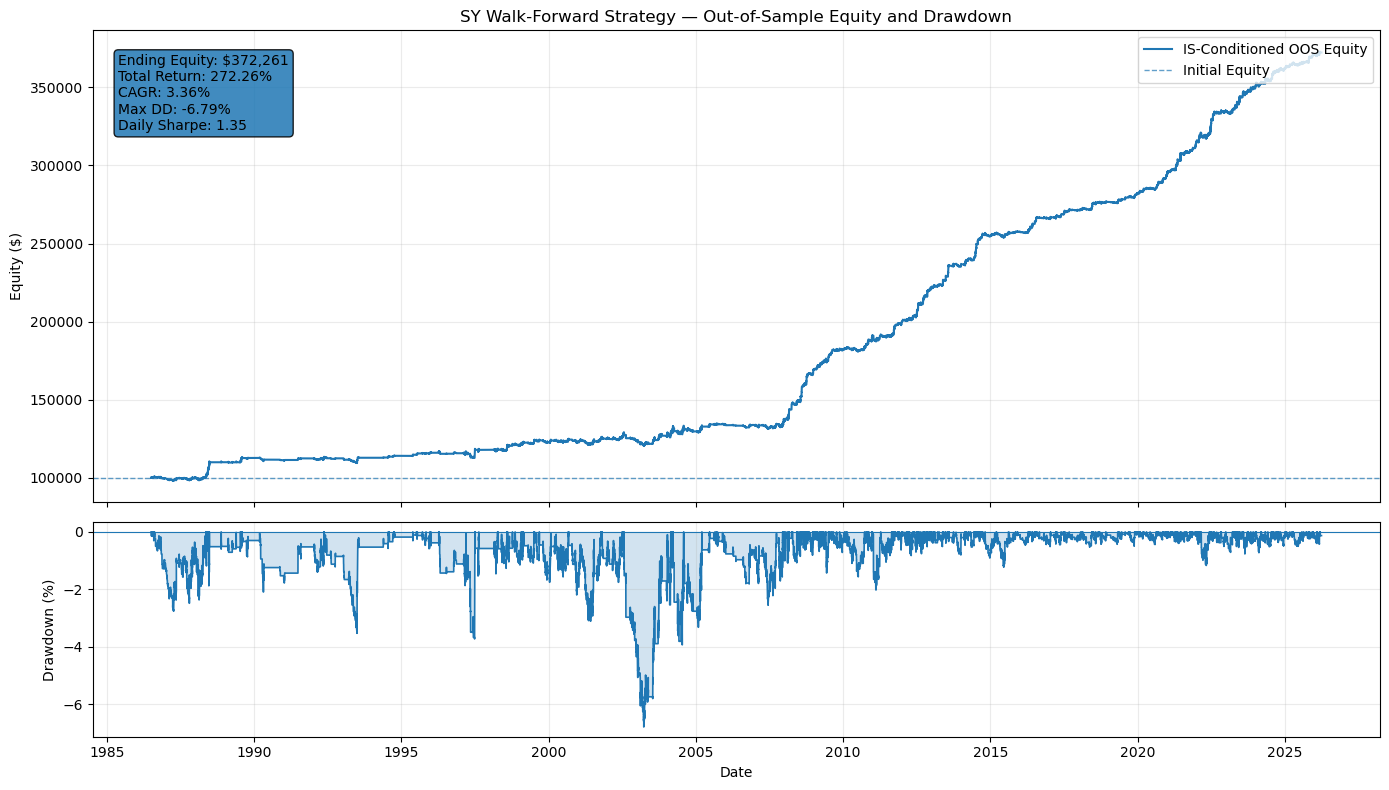

In [37]:
# ------------------------------------------------------------
# Prepare plotting data
# ------------------------------------------------------------

plot_oos = (
    conditioned_oos[
        ['ts', 'equity']
    ]
    .copy()
)

equity_values = (
    plot_oos[
        'equity'
    ]
    .to_numpy(
        dtype=np.float64
    )
)

running_peak = (
    np.maximum.accumulate(
        equity_values
    )
)

plot_oos[
    'drawdown_pct'
] = (
    equity_values
    / running_peak
    - 1.0
)


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={
        'height_ratios': [2.2, 1]
    }
)


# ============================================================
# Panel 1 — OOS Equity
# ============================================================

axes[0].plot(
    plot_oos['ts'],
    plot_oos['equity'],
    linewidth=1.5,
    label='IS-Conditioned OOS Equity'
)

axes[0].axhline(
    INITIAL_EQUITY,
    linestyle='--',
    linewidth=1.0,
    alpha=0.7,
    label='Initial Equity'
)

axes[0].set_ylabel(
    'Equity ($)'
)

axes[0].set_title(
    'SY Walk-Forward Strategy — '
    'Out-of-Sample Equity and Drawdown'
)

axes[0].grid(
    True,
    alpha=0.25
)

axes[0].legend(
    loc='upper right'
)


# ============================================================
# Panel 2 — Drawdown
# ============================================================

axes[1].plot(
    plot_oos['ts'],
    plot_oos['drawdown_pct'] * 100,
    linewidth=1.2
)

axes[1].fill_between(
    plot_oos['ts'],
    plot_oos['drawdown_pct'] * 100,
    0,
    alpha=0.20
)

axes[1].axhline(
    0,
    linewidth=0.8
)

axes[1].set_ylabel(
    'Drawdown (%)'
)

axes[1].set_xlabel(
    'Date'
)

axes[1].grid(
    True,
    alpha=0.25
)


# ------------------------------------------------------------
# Performance annotation
# ------------------------------------------------------------

performance_text = (
    f'Ending Equity: ${ending_equity:,.0f}\n'
    f'Total Return: {total_return:.2%}\n'
    f'CAGR: {cagr:.2%}\n'
    f'Max DD: {max_drawdown_pct:.2%}\n'
    f'Daily Sharpe: {daily_sharpe:.2f}'
)

axes[0].text(
    0.02,
    0.95,
    performance_text,
    transform=axes[0].transAxes,
    verticalalignment='top',
    bbox={
        'boxstyle': 'round',
        'alpha': 0.85
    }
)


plt.tight_layout()
plt.show()

### 6H. Walk-Forward Parameter Stability

The optimal channel length and trailing-stop percentage selected from each
four-year in-sample window are tracked through time.

Parameter variation across quarterly re-estimation windows provides a direct
diagnostic of model stability and helps identify whether performance depends on
a narrow, persistent parameter configuration or adapts across market regimes.

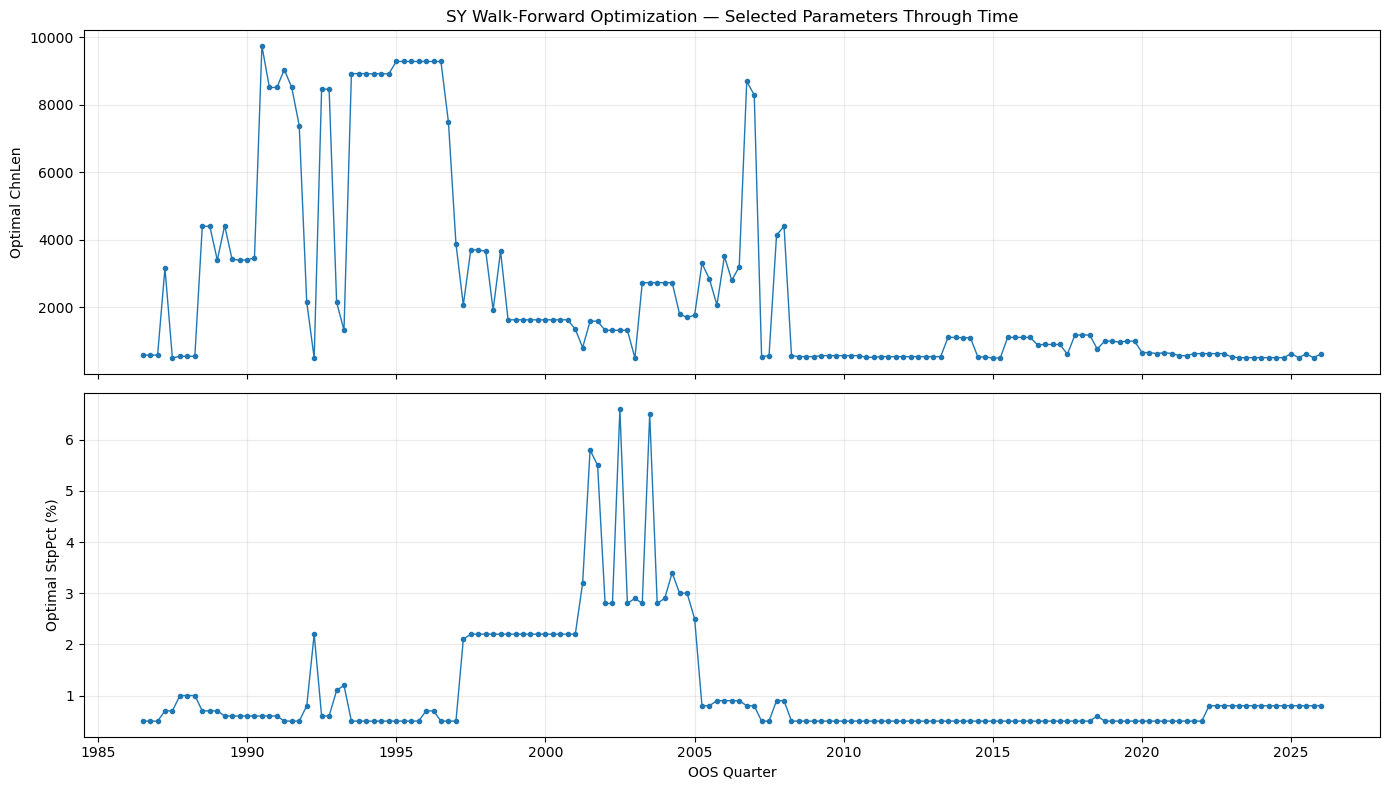

WALK-FORWARD PARAMETER SUMMARY


,Statistic,Value
0,Number of OOS Windows,159.0000
1,Median ChnLen,"1,110.0000"
2,Mean ChnLen,"2,516.5409"
3,Minimum ChnLen,500.0000
4,Maximum ChnLen,"9,740.0000"
5,Median StpPct,0.0060
6,Mean StpPct,0.0109
7,Minimum StpPct,0.0050
8,Maximum StpPct,0.0660


In [36]:
parameter_history = (
    wf_optimization[
        [
            'Quarter',
            'OOS_Start',
            'Best_ChnLen',
            'Best_StpPct',
            'IS_Objective'
        ]
    ]
    .copy()
)

parameter_history[
    'OOS_Start'
] = pd.to_datetime(
    parameter_history[
        'OOS_Start'
    ]
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)


# ============================================================
# Channel Length
# ============================================================

axes[0].plot(
    parameter_history[
        'OOS_Start'
    ],
    parameter_history[
        'Best_ChnLen'
    ],
    marker='o',
    markersize=3,
    linewidth=1.0
)

axes[0].set_ylabel(
    'Optimal ChnLen'
)

axes[0].set_title(
    'SY Walk-Forward Optimization — '
    'Selected Parameters Through Time'
)

axes[0].grid(
    True,
    alpha=0.25
)


# ============================================================
# Stop Percentage
# ============================================================

axes[1].plot(
    parameter_history[
        'OOS_Start'
    ],
    parameter_history[
        'Best_StpPct'
    ] * 100,
    marker='o',
    markersize=3,
    linewidth=1.0
)

axes[1].set_ylabel(
    'Optimal StpPct (%)'
)

axes[1].set_xlabel(
    'OOS Quarter'
)

axes[1].grid(
    True,
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# Parameter summary
# ============================================================

parameter_summary = pd.DataFrame({
    'Statistic': [
        'Number of OOS Windows',
        'Median ChnLen',
        'Mean ChnLen',
        'Minimum ChnLen',
        'Maximum ChnLen',
        'Median StpPct',
        'Mean StpPct',
        'Minimum StpPct',
        'Maximum StpPct'
    ],

    'Value': [
        len(
            parameter_history
        ),

        parameter_history[
            'Best_ChnLen'
        ].median(),

        parameter_history[
            'Best_ChnLen'
        ].mean(),

        parameter_history[
            'Best_ChnLen'
        ].min(),

        parameter_history[
            'Best_ChnLen'
        ].max(),

        parameter_history[
            'Best_StpPct'
        ].median(),

        parameter_history[
            'Best_StpPct'
        ].mean(),

        parameter_history[
            'Best_StpPct'
        ].min(),

        parameter_history[
            'Best_StpPct'
        ].max()
    ]
})


print('=' * 76)
print('WALK-FORWARD PARAMETER SUMMARY')
print('=' * 76)

parameter_summary

### 6I. Walk-Forward Findings

The exhaustive walk-forward analysis produces a positive and relatively smooth
out-of-sample equity trajectory over the 1986–2026 evaluation period. Starting
from $100,000, the IS-conditioned OOS strategy reaches approximately $372,261,
corresponding to a 272.26% cumulative return and a 3.36% CAGR. The maximum
percentage drawdown is -6.79%, while the annualized Sharpe ratio computed from
daily equity returns is 1.35.

Trade-level results are consistent with the asymmetric payoff profile expected
from a trend-following strategy. Among 2,101 completed OOS trades, the win rate
is 43.65%, but the average winner ($547.28) is substantially larger than the
average loser (-$214.73), producing a profit factor of 1.97 and positive
expectancy of $117.86 per completed trade. Completed-trade statistics exclude
positions crossing IS/OOS or quarter-end boundaries, while all OOS P&L from
those positions remains included in portfolio-level performance.

The optimized parameters are not constant through time. Earlier windows often
favor substantially longer channel lengths, whereas the later sample generally
selects shorter breakout horizons. The stop parameter also varies across market
regimes, with unusually wide optimal stops appearing in parts of the early-2000s
sample and substantially tighter stops dominating more recent periods.

A notable feature is the frequent selection of the 0.5% lower bound for
`StpPct`, particularly in the later sample. Because 0.5% is the prescribed lower
boundary of the optimization grid, these observations should be interpreted as
boundary solutions rather than evidence that 0.5% is necessarily the
unconstrained optimum. Parameter-boundary sensitivity is therefore examined
separately in the subsequent robustness analysis.

Overall, the walk-forward results provide evidence that the channel strategy
retains economically meaningful performance outside the optimization sample,
while also showing that its preferred parameterization is regime-dependent
rather than structurally constant.